# Phân tích Hồi quy (Regression) trên tập dữ liệu Bike Sharing

Cài đặt các thuật toán học máy từ đầu (Numpy) cho phần Linear Regression và Regularization, và sử dụng Sklearn cho các hàm nâng cao.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Lưu trữ kết quả kiểm định, test prediction của mọi mô hình
test_errors_dict = {}
cv_scores_dict = {}
residuals_dict = {}
preds_dict = {}
metrics_list = []

## 1. Đọc dữ Liệu

In [2]:
train_df = pd.read_csv("../../data/train.csv")
val_df = pd.read_csv("../../data/val.csv")
test_df = pd.read_csv("../../data/test.csv")

features_to_drop = ["instant", "dteday", "casual", "registered"]


def prepare_data(df):
    df = df.drop(columns=features_to_drop, errors="ignore")
    X = df.drop(columns=["cnt"]).values
    y = df["cnt"].values
    return X, y


X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)
X_test, y_test = prepare_data(test_df)

# Không chuẩn hoá do dữ liệu (temp, hum, windspeed...) đã được scale sẵn
X_train_scaled = X_train
X_val_scaled = X_val
X_test_scaled = X_test

X_train_scaled_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_scaled_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_scaled_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]


# Cơ chế K-Fold CV + Test Evaluation tự động cho tất cả các mô hình
def evaluate_model(
    model_name,
    fit_predict_fn,
    X_tr_full,
    y_tr_full,
    X_te_full,
    y_te_full,
    X_va_full=None,
    y_va_full=None,
):
    # Combine Train and Val for K-Fold CV if Val is provided
    if X_va_full is not None and y_va_full is not None:
        X_cv = np.vstack((X_tr_full, X_va_full))
        y_cv = np.concatenate((y_tr_full, y_va_full))
    else:
        X_cv = X_tr_full
        y_cv = y_tr_full

    # 1. 10-Fold CV trên tập Train+Val (Dùng Sklearn Library)
    kf = KFold(n_splits=10, shuffle=False)
    cv_mse = []
    cv_rmse = []
    cv_mae = []
    cv_r2 = []
    for train_index, val_index in kf.split(X_cv):
        X_fold_train, X_fold_val = X_cv[train_index], X_cv[val_index]
        y_fold_train, y_fold_val = y_cv[train_index], y_cv[val_index]

        y_val_pred, _ = fit_predict_fn(X_fold_train, y_fold_train, X_fold_val)

        mse = np.mean((y_fold_val - y_val_pred) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_fold_val - y_val_pred))
        r2 = 1 - (
            np.sum((y_fold_val - y_val_pred) ** 2)
            / np.sum((y_fold_val - np.mean(y_fold_val)) ** 2)
        )
        cv_mse.append(mse)
        cv_rmse.append(rmse)
        cv_mae.append(mae)
        cv_r2.append(r2)

    mean_cv_mse = np.mean(cv_mse)
    std_cv_mse = np.std(cv_mse)
    mean_cv_rmse = np.mean(cv_rmse)
    std_cv_rmse = np.std(cv_rmse)
    mean_cv_mae = np.mean(cv_mae)
    std_cv_mae = np.std(cv_mae)
    mean_cv_r2 = np.mean(cv_r2)
    std_cv_r2 = np.std(cv_r2)

    cv_scores_dict[model_name] = np.array(cv_rmse)

    # 1.5 Validation Set Evaluation
    if X_va_full is not None and y_va_full is not None:
        y_val_pred, _ = fit_predict_fn(X_cv, y_cv, X_va_full)
        val_mse = np.mean((y_va_full - y_val_pred) ** 2)
        val_rmse = np.sqrt(val_mse)
        val_mae = np.mean(np.abs(y_va_full - y_val_pred))
        val_r2 = 1 - (
            np.sum((y_va_full - y_val_pred) ** 2)
            / np.sum((y_va_full - np.mean(y_va_full)) ** 2)
        )
    else:
        val_mse, val_rmse, val_mae, val_r2 = None, None, None, None

    # 2. Test Set Evaluation
    y_test_pred, final_model = fit_predict_fn(X_cv, y_cv, X_te_full)
    test_mse = np.mean((y_te_full - y_test_pred) ** 2)
    test_rmse = np.sqrt(test_mse)
    test_mae = np.mean(np.abs(y_te_full - y_test_pred))
    test_r2 = 1 - (
        np.sum((y_te_full - y_test_pred) ** 2)
        / np.sum((y_te_full - np.mean(y_te_full)) ** 2)
    )

    # Save absolute errors for Wilcoxon Rank Sum test sau cùng
    abs_errors = np.abs(y_te_full - y_test_pred)
    test_errors_dict[model_name] = abs_errors
    residuals_dict[model_name] = y_te_full - y_test_pred
    preds_dict[model_name] = y_test_pred

    # 3. Thêm Metric và In ra kết quả trực tiếp
    metric_dict = {
        "Model": model_name,
        "CV_MSE (Mean ± Std)": f"{mean_cv_mse:.2f} ± {std_cv_mse:.2f}",
        "CV_RMSE (Mean ± Std)": f"{mean_cv_rmse:.2f} ± {std_cv_rmse:.2f}",
        "CV_MAE (Mean ± Std)": f"{mean_cv_mae:.2f} ± {std_cv_mae:.2f}",
        "CV_R2 (Mean ± Std)": f"{mean_cv_r2:.4f} ± {std_cv_r2:.4f}",
    }
    if val_mse is not None:
        metric_dict["Val MSE"] = val_mse
        metric_dict["Val RMSE"] = val_rmse
        metric_dict["Val MAE"] = val_mae
        metric_dict["Val R2"] = val_r2

    metric_dict.update(
        {
            "Test MSE": test_mse,
            "Test RMSE": test_rmse,
            "Test MAE": test_mae,
            "Test R2": test_r2,
        }
    )
    metrics_list.append(metric_dict)

    print(f"[{model_name}] Kết quả đánh giá:")
    for key, value in metric_dict.items():
        if key != "Model":
            if isinstance(value, float):
                print(f"  - {key}: {value:.4f}")
            else:
                print(f"  - {key}: {value}")

    # 4. Tự động vẽ Plot Actual/Residual ngay lập tức
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_te_full, y_test_pred, alpha=0.3, color="teal")
    axes[0].plot(
        [y_te_full.min(), y_te_full.max()],
        [y_te_full.min(), y_te_full.max()],
        "r--",
        lw=2,
    )
    axes[0].set_xlabel("Thực tế (Actual)")
    axes[0].set_ylabel("Dự đoán (Predicted)")
    axes[0].set_title(f"{model_name}: Actual vs Predicted")

    # Vẽ Scatter Plot kiểm tra tính ngẫu nhiên (homoscedasticity)
    residuals = y_te_full - y_test_pred
    axes[1].scatter(y_test_pred, residuals, alpha=0.3, color="coral")
    axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
    axes[1].set_xlabel("Dự đoán (Predicted)")
    axes[1].set_ylabel("Residuals (Thực tế - Dự đoán)")
    axes[1].set_title(f"{model_name}: Residuals vs Predicted")

    plt.tight_layout()
    plt.show()
    return final_model


# Helper Hàm vẽ Learning Curve theo lượng data (Data Size)
def plot_learning_curve_data_size(
    model_name,
    fit_predict_fn,
    X_tr_full,
    y_tr_full,
    X_val_full,
    y_val_full,
    num_points=10,
):
    train_sizes = np.linspace(0.1, 1.0, num_points)
    train_scores = []
    val_scores = []

    for size in train_sizes:
        subset_len = int(size * len(X_tr_full))
        subset_len = max(10, subset_len)  # Đảm bảo có ít nhất 10 mẫu để fit
        X_sub = X_tr_full[:subset_len]
        y_sub = y_tr_full[:subset_len]

        y_train_pred, _ = fit_predict_fn(X_sub, y_sub, X_sub)
        y_val_pred, _ = fit_predict_fn(X_sub, y_sub, X_val_full)

        train_mse = np.mean((y_sub - y_train_pred) ** 2)
        val_mse = np.mean((y_val_full - y_val_pred) ** 2)

        train_scores.append(train_mse)
        val_scores.append(val_mse)

    plt.figure(figsize=(10, 6))
    plt.plot(
        train_sizes * len(X_tr_full),
        train_scores,
        label="Train MSE",
        marker="o",
        color="teal",
    )
    plt.plot(
        train_sizes * len(X_tr_full),
        val_scores,
        label="Validation MSE",
        marker="x",
        color="coral",
    )
    plt.xlabel("Số lượng mẫu huấn luyện (Training Set Size)")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.title(f"Learning Curve vs Mẫu Data ({model_name})")
    plt.legend()
    plt.show()

## 2. Hồi quy Tuyến Tính (Thuần Numpy)
### 2.1 Normal Equations

[Normal Equations OLS] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17711.93 ± 9423.90
  - CV_RMSE (Mean ± Std): 128.49 ± 34.69
  - CV_MAE (Mean ± Std): 99.67 ± 29.57
  - CV_R2 (Mean ± Std): 0.1664 ± 0.2959
  - Val MSE: 33622.1540
  - Val RMSE: 183.3634
  - Val MAE: 148.9251
  - Val R2: 0.2983
  - Test MSE: 33590.7693
  - Test RMSE: 183.2778
  - Test MAE: 138.2918
  - Test R2: 0.3090


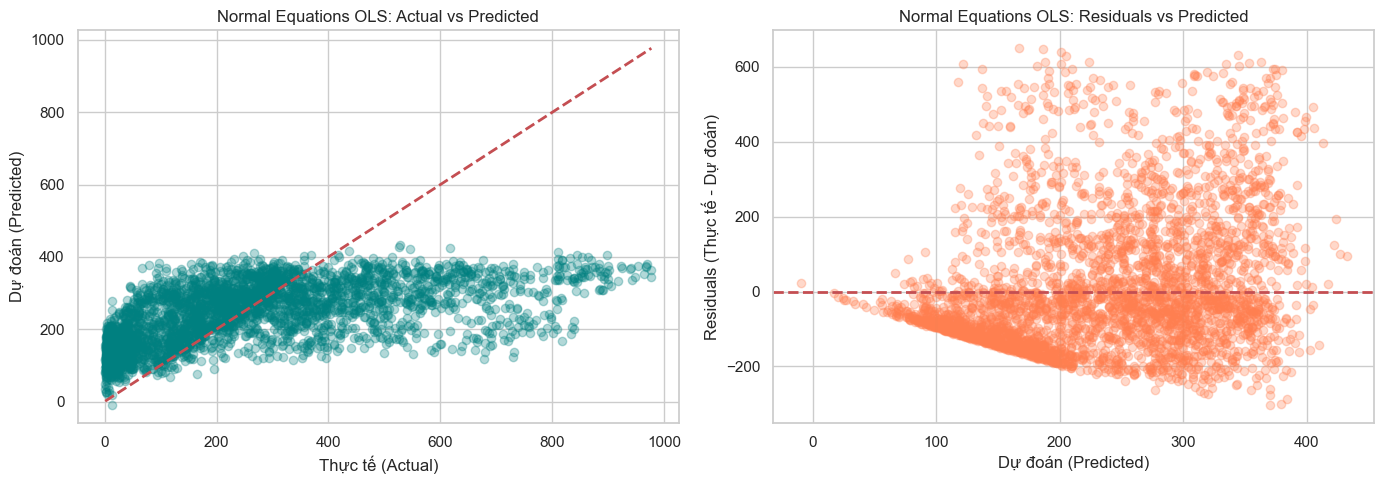

In [3]:
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_val_b = np.c_[np.ones((X_val.shape[0], 1)), X_val]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]


def fit_pred_ols(X_tr, y_tr, X_val):
    w = np.linalg.pinv(X_tr.T.dot(X_tr)).dot(X_tr.T).dot(y_tr)
    return X_val.dot(w), w


model_ols = evaluate_model(
    "Normal Equations OLS",
    fit_pred_ols,
    X_train_b,
    y_train,
    X_test_b,
    y_test,
    X_val_b,
    y_val,
)

from sklearn.model_selection import learning_curve


def plot_sklearn_learning_curve_wrapper(estimator, title, X, y, cv=5):
    # Sử dụng learning_curve tích hợp sẵn để linh hoạt thay đổi train_sizes kích thước dữ liệu
    train_sizes, train_scores, test_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1,
    )

    # Chuyển về Root Mean Squared Error (RMSE) dương
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Training error")
    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    plt.plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation error"
    )
    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )

    plt.title(f"Learning Curve (Train Size): {title}")
    plt.xlabel("Số lượng mẫu phân chia huấn luyện")
    plt.ylabel("RMSE (Thấp là tốt)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

#### So sánh với Sklearn LinearRegression
Chạy mô hình hàm chuẩn `LinearRegression` của thư viện Sklearn để đối chiếu tính chính xác của thuật toán (Numpy) mà chúng ta tự cài.

[Sklearn Linear Regression] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17711.93 ± 9423.90
  - CV_RMSE (Mean ± Std): 128.49 ± 34.69
  - CV_MAE (Mean ± Std): 99.67 ± 29.57
  - CV_R2 (Mean ± Std): 0.1664 ± 0.2959
  - Val MSE: 33622.1540
  - Val RMSE: 183.3634
  - Val MAE: 148.9251
  - Val R2: 0.2983
  - Test MSE: 33590.7693
  - Test RMSE: 183.2778
  - Test MAE: 138.2918
  - Test R2: 0.3090


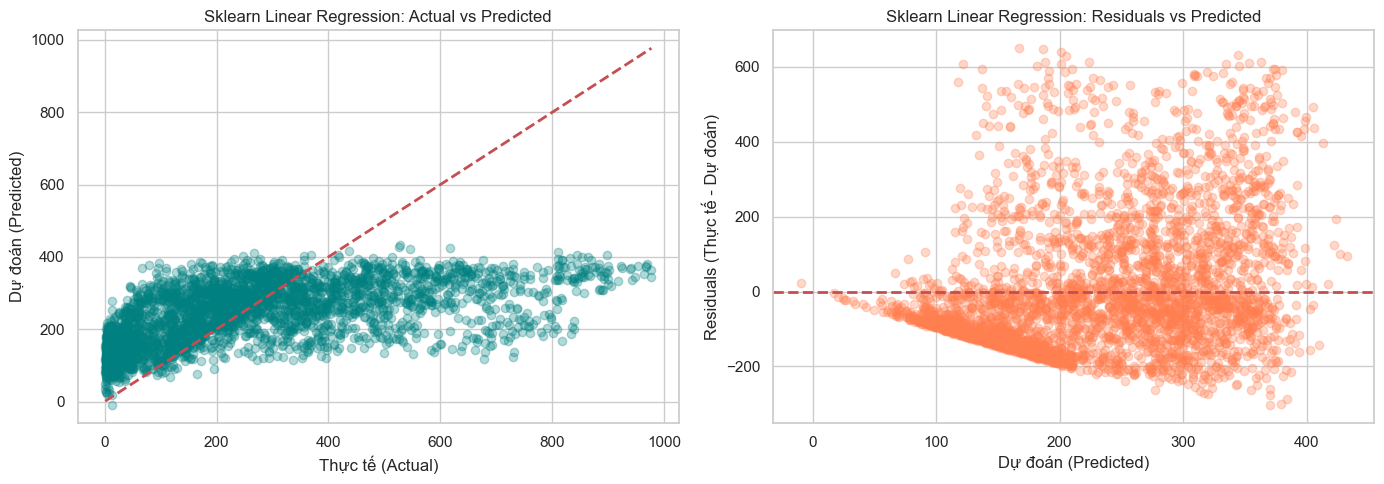

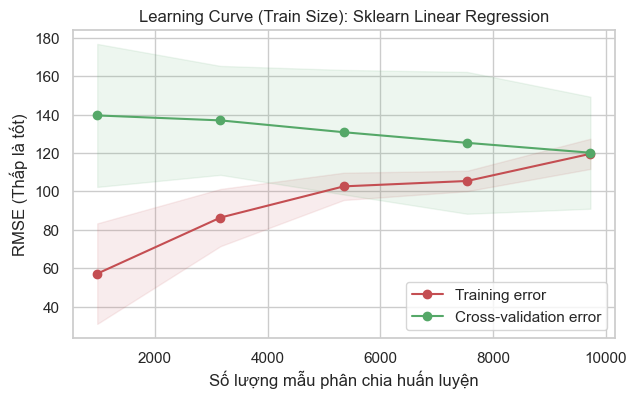


SO SÁNH NUMPY OLS VÀ SKLEARN LINEAR REGRESSION
Chênh lệch dự đoán lớn nhất (Max Pred Diff): 4.7634785005e-11
Chênh lệch trọng số lớn nhất (Max Weight Diff): 6.0481397668e-11
=> KẾT LUẬN: Cài đặt OLS thủ công bằng Numpy khớp hoàn toàn với Sklearn!


In [4]:
from sklearn.linear_model import LinearRegression


def fit_pred_sk_ols(X_tr, y_tr, X_val):
    model = LinearRegression(fit_intercept=False)
    model.fit(X_tr, y_tr)
    return model.predict(X_val), model


model_sk_ols = evaluate_model(
    "Sklearn Linear Regression",
    fit_pred_sk_ols,
    X_train_b,
    y_train,
    X_test_b,
    y_test,
    X_val_b,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    LinearRegression(fit_intercept=False),
    "Sklearn Linear Regression",
    X_train_b,
    y_train,
)

print("\n" + "=" * 50)
print("SO SÁNH NUMPY OLS VÀ SKLEARN LINEAR REGRESSION")
print("=" * 50)

max_pred_diff = np.max(
    np.abs(preds_dict["Normal Equations OLS"] - preds_dict["Sklearn Linear Regression"])
)
w_sk = model_sk_ols.coef_
# model_ols (Numpy) trả về ma trận (hoặc vector) weights
max_weight_diff = np.max(np.abs(model_ols - w_sk))

print(f"Chênh lệch dự đoán lớn nhất (Max Pred Diff): {max_pred_diff:.10e}")
print(f"Chênh lệch trọng số lớn nhất (Max Weight Diff): {max_weight_diff:.10e}")

if np.allclose(
    preds_dict["Normal Equations OLS"],
    preds_dict["Sklearn Linear Regression"],
    atol=1e-5,
):
    print("=> KẾT LUẬN: Cài đặt OLS thủ công bằng Numpy khớp hoàn toàn với Sklearn!")
else:
    print("=> KẾT LUẬN: Có biểu hiện sai lệch giữa Numpy và Sklearn.")

### 2.1.1 Kiểm tra giả định Gauss-Markov
Kiểm tra QQ-plot xác định phân phối chuẩn và Breusch-Pagan test kiểm tra Heteroscedasticity.

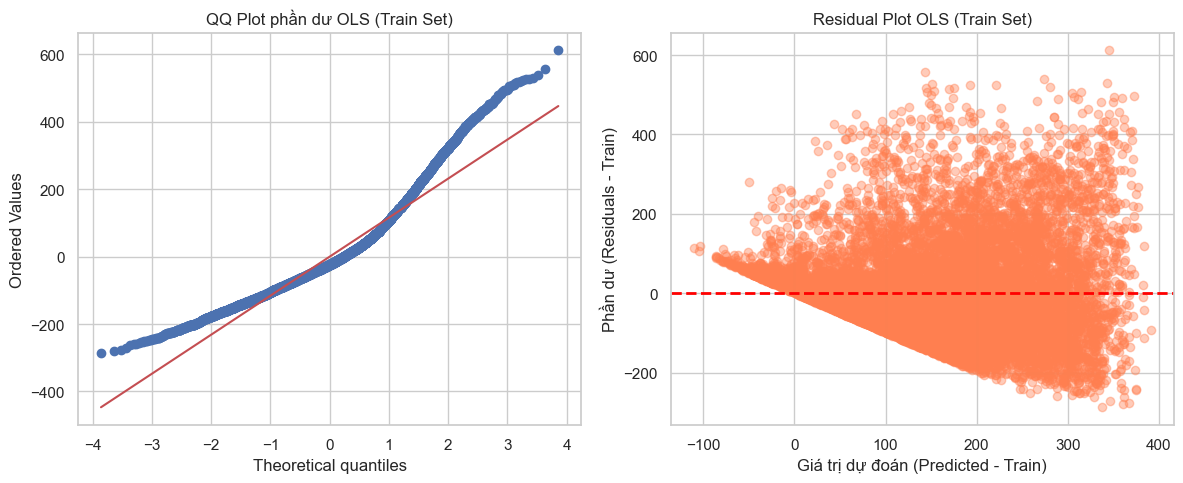

Breusch-Pagan Test (Train): LM Stat = 1093.4954, p-value = 1.4596e-226
Có hiện tượng heteroscedasticity (phương sai sai số thay đổi). Nên dùng WLS.


In [5]:
y_train_pred_ols, _ = fit_pred_ols(X_train_b, y_train, X_train_b)
residuals_train_ols = y_train - y_train_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Kiểm tra tính chuẩn (Normality) qua QQ-Plot trên Train
stats.probplot(residuals_train_ols, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot phần dư OLS (Train Set)")

# 2. Kiểm tra phương sai sai số không đổi (Homoscedasticity) qua Residual Plot trên Train
axes[1].scatter(y_train_pred_ols, residuals_train_ols, alpha=0.4, color="coral")
axes[1].axhline(y=0, color="red", linestyle="--", lw=2)
axes[1].set_xlabel("Giá trị dự đoán (Predicted - Train)")
axes[1].set_ylabel("Phần dư (Residuals - Train)")
axes[1].set_title("Residual Plot OLS (Train Set)")

plt.tight_layout()
plt.show()


def breusch_pagan_test(X, residuals):
    squared_residuals = residuals**2
    w_bp = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(squared_residuals)
    pred_squared_residuals = X.dot(w_bp)

    ss_res = np.sum((squared_residuals - pred_squared_residuals) ** 2)
    ss_tot = np.sum((squared_residuals - np.mean(squared_residuals)) ** 2)
    r2_bp = 1 - (ss_res / ss_tot)

    n = X.shape[0]
    p = X.shape[1] - 1
    lm_stat = n * r2_bp
    p_value = stats.chi2.sf(lm_stat, p)
    return lm_stat, p_value


bp_stat, bp_pval = breusch_pagan_test(X_train_b, residuals_train_ols)
print(f"Breusch-Pagan Test (Train): LM Stat = {bp_stat:.4f}, p-value = {bp_pval:.4e}")
if bp_pval < 0.05:
    print(
        "Có hiện tượng heteroscedasticity (phương sai sai số thay đổi). Nên dùng WLS."
    )
else:
    print("Không có hiện tượng heteroscedasticity.")

### 2.2 Mini-batch Gradient Descent
Biểu đồ Learning curve của hệ thống huấn luyện lặp theo kỉ nguyên

[Mini-Batch GD] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17669.01 ± 9478.70
  - CV_RMSE (Mean ± Std): 128.25 ± 34.94
  - CV_MAE (Mean ± Std): 99.60 ± 29.75
  - CV_R2 (Mean ± Std): 0.1715 ± 0.2909
  - Val MSE: 33663.0489
  - Val RMSE: 183.4749
  - Val MAE: 149.2077
  - Val R2: 0.2975
  - Test MSE: 33645.6517
  - Test RMSE: 183.4275
  - Test MAE: 138.5376
  - Test R2: 0.3079


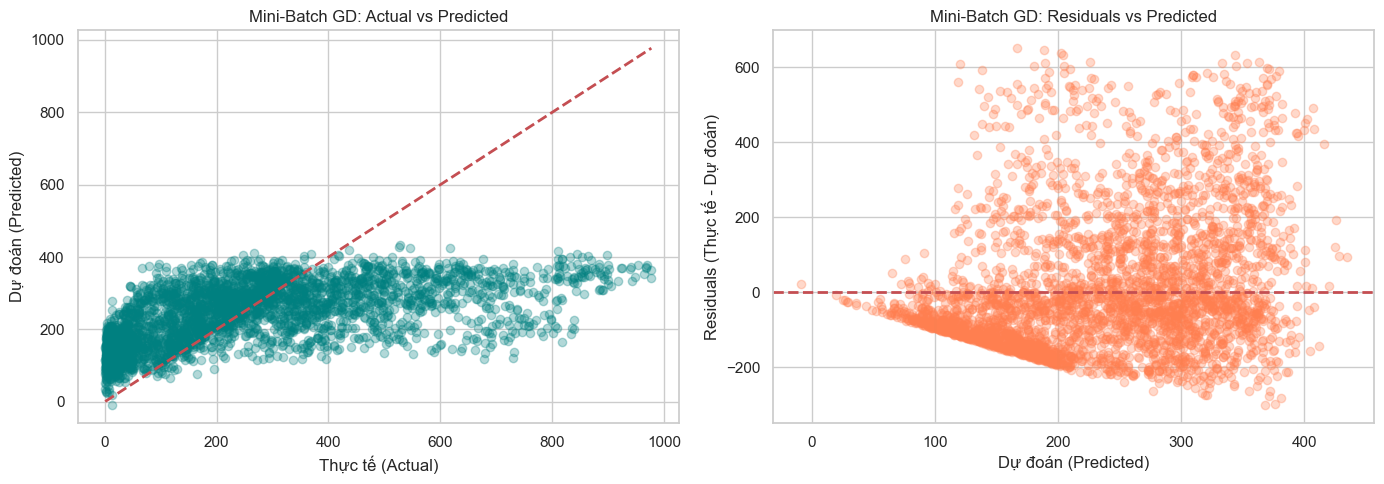

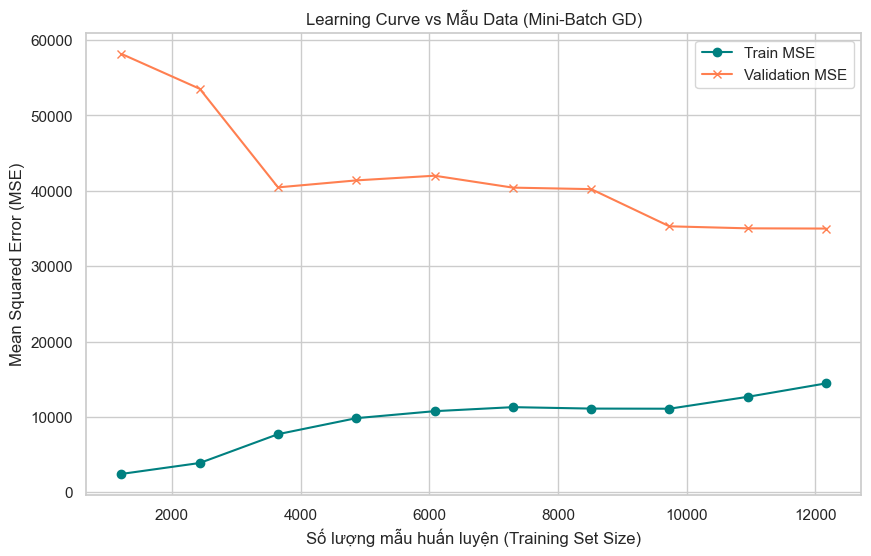

In [6]:
def minibatch_gd(X, y, epochs=100, batch_size=128, lr_init=0.01):
    m, n_features = X.shape
    np.random.seed(42)
    w = np.random.randn(n_features) * 0.01
    losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        lr = lr_init * 0.5 * (1 + np.cos(np.pi * epoch / epochs))

        epoch_loss = 0
        for i in range(0, m, batch_size):
            X_i = X_shuffled[i : i + batch_size]
            y_i = y_shuffled[i : i + batch_size]

            predictions = X_i.dot(w)
            error = predictions - y_i
            epoch_loss += np.sum(error**2)

            gradient = (1 / batch_size) * X_i.T.dot(error)
            # Add gradient clipping to prevent exploding gradients (NaN)
            gradient = np.clip(gradient, -10000, 10000)
            w -= lr * gradient

        losses.append(epoch_loss / m)

    return w, losses


# Lấy w_gd dùng sau nếu cần (hoặc chỉ quan sát quá trình chạy cơ bản)
w_gd, _ = minibatch_gd(
    X_train_scaled_b, y_train, epochs=200, batch_size=128, lr_init=0.01
)


def fit_pred_gd(X_tr, y_tr, X_val):
    w, _ = minibatch_gd(X_tr, y_tr, epochs=200, batch_size=128, lr_init=0.01)
    return X_val.dot(w), w


_ = evaluate_model(
    "Mini-Batch GD",
    fit_pred_gd,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
    X_val_scaled_b,
    y_val,
)

plot_learning_curve_data_size(
    "Mini-Batch GD", fit_pred_gd, X_train_scaled_b, y_train, X_val_scaled_b, y_val
)

### So sánh thời gian hội tụ (Training Time) giữa OLS và Mini-Batch GD
Đo lường tốc độ thực thi thuần tuý của công thức đại số tuyến tính so với vòng lặp tối ưu Gradient Descent.

SO SÁNH THỜI GIAN HUẤN LUYỆN (OLS vs Mini-Batch GD)
Thời gian OLS (Normal Equations): 0.00206 giây
Thời gian Mini-Batch GD (200 epochs): 0.79258 giây
=> OLS hội tụ nhanh hơn 384.93 lần so với Mini-Batch GD trên tập dữ liệu này.


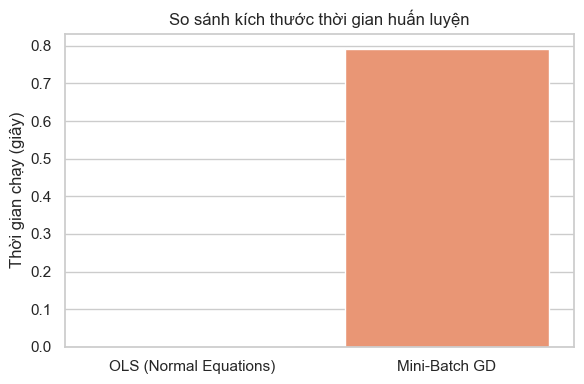

In [7]:
import time

# 1. Đo thời gian Normal Equations (OLS)
start_ols = time.process_time()
_ = np.linalg.pinv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)
time_ols = time.process_time() - start_ols

# 2. Đo thời gian Mini-Batch Gradient Descent
start_gd = time.process_time()
_, _ = minibatch_gd(X_train_scaled_b, y_train, epochs=200, batch_size=128, lr_init=0.01)
time_gd = time.process_time() - start_gd

print("=" * 60)
print("SO SÁNH THỜI GIAN HUẤN LUYỆN (OLS vs Mini-Batch GD)")
print("=" * 60)
print(f"Thời gian OLS (Normal Equations): {time_ols:.5f} giây")
print(f"Thời gian Mini-Batch GD (200 epochs): {time_gd:.5f} giây")

if time_ols < time_gd:
    print(
        f"=> OLS hội tụ nhanh hơn {time_gd / time_ols:.2f} lần so với Mini-Batch GD trên tập dữ liệu này."
    )
else:
    print(f"=> Mini-Batch GD hội tụ nhanh hơn {time_ols / time_gd:.2f} lần so với OLS.")

# Vẽ biểu đồ cột để minh hoạ trực quan
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["OLS (Normal Equations)", "Mini-Batch GD"], y=[time_ols, time_gd], palette="Set2"
)
plt.ylabel("Thời gian chạy (giây)")
plt.title("So sánh kích thước thời gian huấn luyện")
plt.tight_layout()
plt.show()

### 2.3 WLS (Feasible Generalized Least Squares)

[WLS] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 18057.53 ± 10290.89
  - CV_RMSE (Mean ± Std): 129.06 ± 37.41
  - CV_MAE (Mean ± Std): 98.75 ± 28.82
  - CV_R2 (Mean ± Std): 0.1740 ± 0.2686
  - Val MSE: 35453.4562
  - Val RMSE: 188.2909
  - Val MAE: 146.3070
  - Val R2: 0.2601
  - Test MSE: 36415.9856
  - Test RMSE: 190.8297
  - Test MAE: 139.0330
  - Test R2: 0.2509


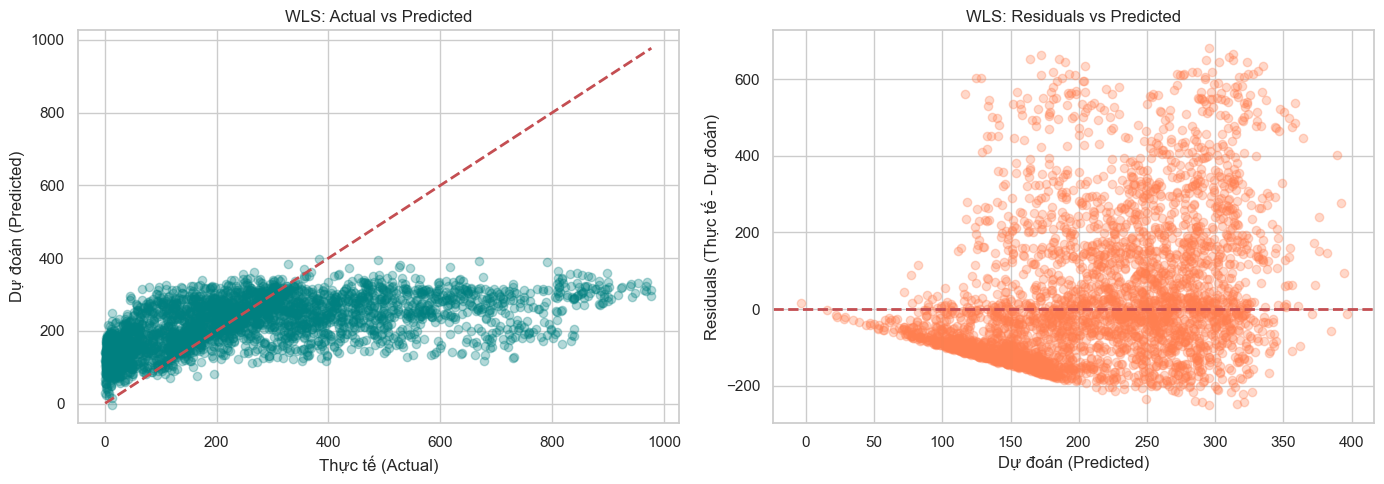

In [8]:
def fit_pred_wls(X_tr, y_tr, X_val):
    # Bước 1: Fit OLS thông thường
    w_ols = np.linalg.pinv(X_tr.T.dot(X_tr)).dot(X_tr.T).dot(y_tr)
    y_pred_tr = X_tr.dot(w_ols)
    residuals_abs = np.abs(y_tr - y_pred_tr)

    # Bước 2: Hồi quy phần dư tuyệt đối theo X để dự đoán phương sai phân phối tại từng điểm (Auxiliary FGLS)
    w_aux = np.linalg.pinv(X_tr.T.dot(X_tr)).dot(X_tr.T).dot(residuals_abs)
    volatility_est = X_tr.dot(w_aux)

    # Cắt các giá trị dự đoán rủi ro âm/gần 0
    volatility_est = np.clip(volatility_est, a_min=1e-5, a_max=None)

    # Bước 3: Tạo trọng số W = 1 / Var = 1 / (volatility_est^2)
    weights_tr = 1.0 / (volatility_est**2)

    # Bước 4: Fit WLS sử dụng nhân vector thay vì sinh ma trận đường chéo khổng lồ
    XTw_X = (X_tr * weights_tr[:, None]).T.dot(X_tr)
    XTw_y = (X_tr * weights_tr[:, None]).T.dot(y_tr)
    w_wls = np.linalg.pinv(XTw_X).dot(XTw_y)

    return X_val.dot(w_wls), w_wls


_ = evaluate_model(
    "WLS", fit_pred_wls, X_train_b, y_train, X_test_b, y_test, X_val_b, y_val
)

## 3. Hồi quy Regularization

### 3.1 Ridge Regression (L2)

Optimal Lambda (Ridge): 0.7279


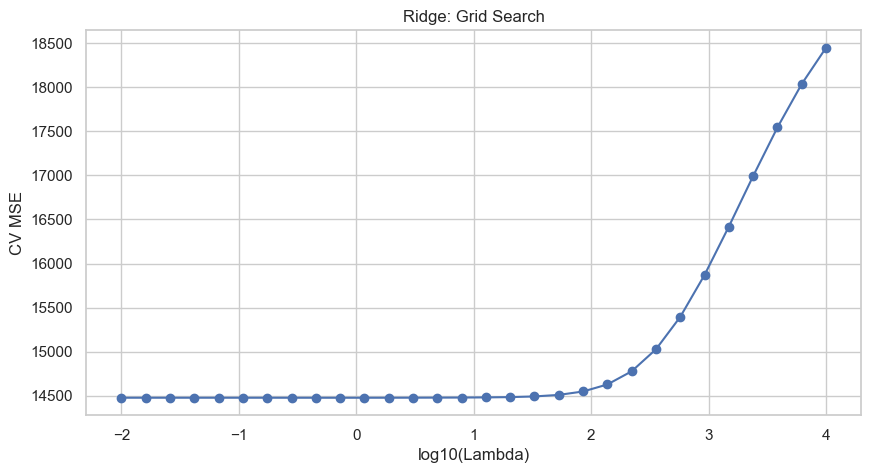

In [13]:
from sklearn.linear_model import Ridge

def ridge_closed_form(X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # Không regularize bias
    return np.linalg.pinv(X.T @ X + lam * I) @ X.T @ y


def ridge_cv(X, y, lambdas):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_errors = []

    for lam in lambdas:
        fold_errs = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            w = ridge_closed_form(X_tr, y_tr, lam)
            y_pred = X_val @ w
            fold_errs.append(np.mean((y_val - y_pred) ** 2))

        cv_errors.append(np.mean(fold_errs))

    best_idx = np.argmin(cv_errors)
    return lambdas[best_idx], cv_errors


# Grid search
lambdas_ridge = np.logspace(-2, 4, 30)
best_lam_ridge, cv_errs_ridge = ridge_cv(X_train_scaled_b, y_train, lambdas_ridge)

print(f"Optimal Lambda (Ridge): {best_lam_ridge:.4f}")

# Plot CV curve
plt.figure(figsize=(10, 5))
plt.plot(np.log10(lambdas_ridge), cv_errs_ridge, marker="o")
plt.xlabel("log10(Lambda)")
plt.ylabel("CV MSE")
plt.title("Ridge: Grid Search")
plt.show()

#### Regularization Path (Ridge)

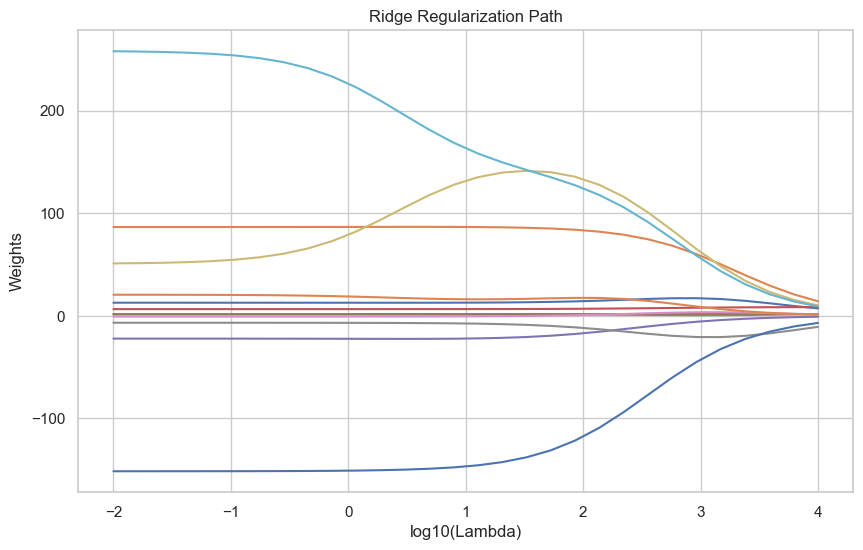

In [14]:
weights_ridge = []
for lam in lambdas_ridge:
    w = ridge_closed_form(X_train_scaled_b, y_train, lam)
    weights_ridge.append(w[1:])  # bỏ bias

weights_ridge = np.array(weights_ridge)

plt.figure(figsize=(10, 6))
for i in range(weights_ridge.shape[1]):
    plt.plot(np.log10(lambdas_ridge), weights_ridge[:, i])
plt.xlabel("log10(Lambda)")
plt.ylabel("Weights")
plt.title("Ridge Regularization Path")
plt.show()

[Ridge (L2)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 15019.74 ± 7486.94
  - CV_RMSE (Mean ± Std): 118.83 ± 29.99
  - CV_MAE (Mean ± Std): 92.20 ± 24.46
  - CV_R2 (Mean ± Std): 0.1656 ± 0.2840
  - Test MSE: 33654.5231
  - Test RMSE: 183.4517
  - Test MAE: 142.3167
  - Test R2: 0.3077


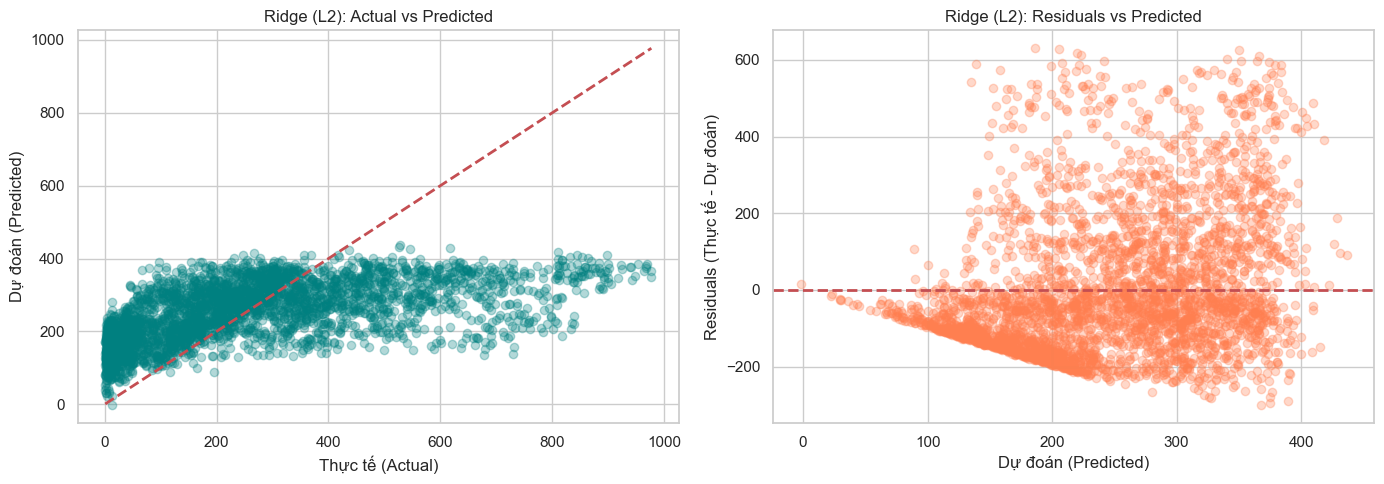

In [20]:
def fit_pred_ridge(X_tr, y_tr, X_val):
    w = ridge_closed_form(X_tr, y_tr, best_lam_ridge)
    return X_val @ w, w


_ = evaluate_model(
    "Ridge (L2)",
    fit_pred_ridge,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
)


# plot_sklearn_learning_curve_wrapper(
#     Ridge(alpha=best_lam_ridge), "Ridge Regression", X_train_scaled, y_train
# )

### 3.2 Lasso Regression (L1 - Coordinate Descent)

Optimal Lambda (Lasso): 0.1000


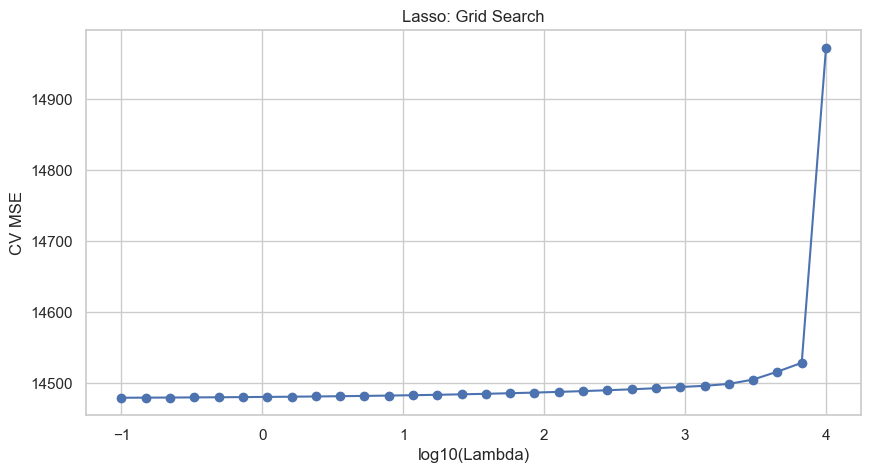

In [21]:
from sklearn.linear_model import Lasso

def soft_threshold(rho, lam):
    if rho < -lam:
        return rho + lam
    elif rho > lam:
        return rho - lam
    return 0.0


def lasso_cd(X, y, lam, epochs=30, w_init=None):
    m, n = X.shape
    w = np.zeros(n) if w_init is None else w_init.copy()
    losses = []

    for _ in range(epochs):
        for j in range(n):
            X_j = X[:, j]
            residual = y - (X @ w - w[j] * X_j)
            rho = X_j.T @ residual

            if j == 0:
                w[j] = rho / (X_j.T @ X_j)
            else:
                w[j] = soft_threshold(rho, lam) / (X_j.T @ X_j)

        loss = np.mean((X @ w - y) ** 2) + lam * np.sum(np.abs(w[1:])) / m
        losses.append(loss)

    return w, losses


def lasso_cv(X, y, lambdas, epochs=30):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_errors = []

    warm_starts = [np.zeros(X.shape[1]) for _ in range(10)]

    for lam in lambdas:
        fold_errs = []
        for i, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            w, _ = lasso_cd(X_tr, y_tr, lam, epochs, warm_starts[i])
            warm_starts[i] = w

            y_pred = X_val @ w
            fold_errs.append(np.mean((y_val - y_pred) ** 2))

        cv_errors.append(np.mean(fold_errs))

    best_idx = np.argmin(cv_errors)
    return lambdas[best_idx], cv_errors


# Grid search
lambdas_lasso = np.logspace(4, -1, 30)
best_lam_lasso, cv_errs_lasso = lasso_cv(X_train_scaled_b, y_train, lambdas_lasso)

print(f"Optimal Lambda (Lasso): {best_lam_lasso:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(np.log10(lambdas_lasso), cv_errs_lasso, marker="o")
plt.xlabel("log10(Lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso: Grid Search")
plt.show()

#### Regularization Path (Lasso)

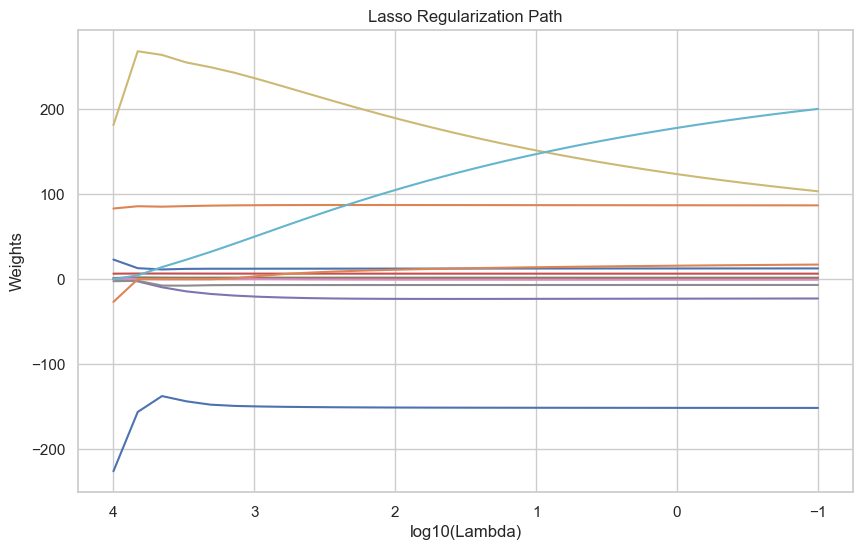

In [22]:
weights_lasso = []
w_warm = np.zeros(X_train_scaled_b.shape[1])

for lam in lambdas_lasso:
    w_warm, _ = lasso_cd(X_train_scaled_b, y_train, lam, epochs=30, w_init=w_warm)
    weights_lasso.append(w_warm[1:])

weights_lasso = np.array(weights_lasso)

plt.figure(figsize=(10, 6))
for i in range(weights_lasso.shape[1]):
    plt.plot(np.log10(lambdas_lasso), weights_lasso[:, i])

plt.gca().invert_xaxis()
plt.xlabel("log10(Lambda)")
plt.ylabel("Weights")
plt.title("Lasso Regularization Path")
plt.show()

[Lasso (L1)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 15296.27 ± 7307.83
  - CV_RMSE (Mean ± Std): 120.21 ± 29.10
  - CV_MAE (Mean ± Std): 93.98 ± 23.86
  - CV_R2 (Mean ± Std): 0.1410 ± 0.2883
  - Test MSE: 33429.3117
  - Test RMSE: 182.8368
  - Test MAE: 145.0945
  - Test R2: 0.3123


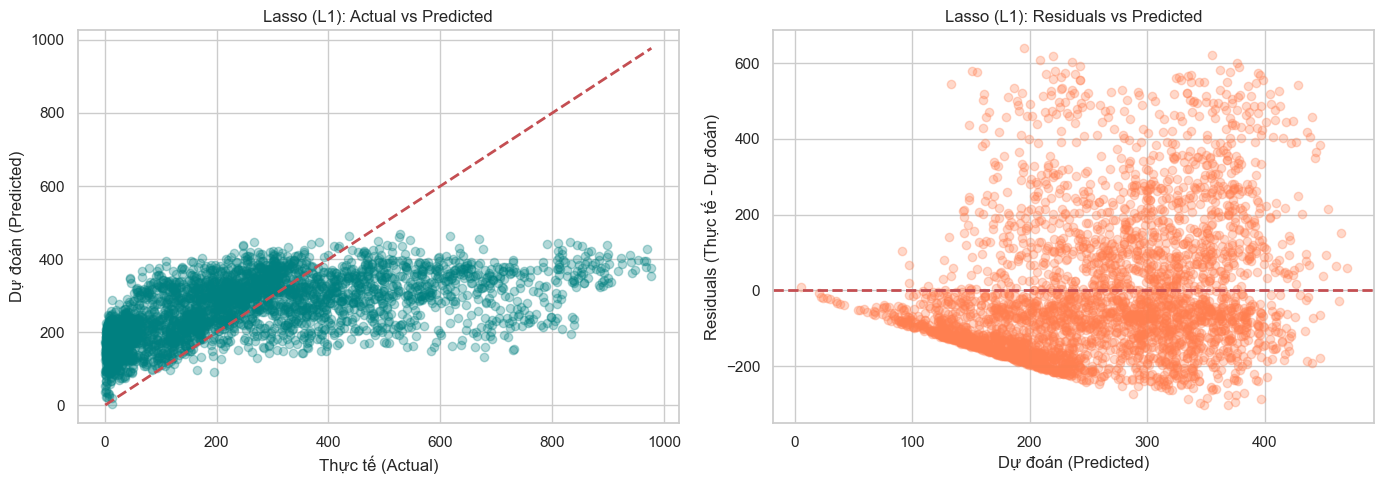

In [23]:
def fit_pred_lasso(X_tr, y_tr, X_val):
    w, _ = lasso_cd(X_tr, y_tr, best_lam_lasso, epochs=50)
    return X_val @ w, w


_ = evaluate_model(
    "Lasso (L1)",
    fit_pred_lasso,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
)

### 3.3 Elastic Net
Biểu đồ Learning Curves hội tụ bằng Coordinate Descent

Optimal Lam1 for Elastic Net: 0.00100
Optimal Lam2 for Elastic Net: 0.00774


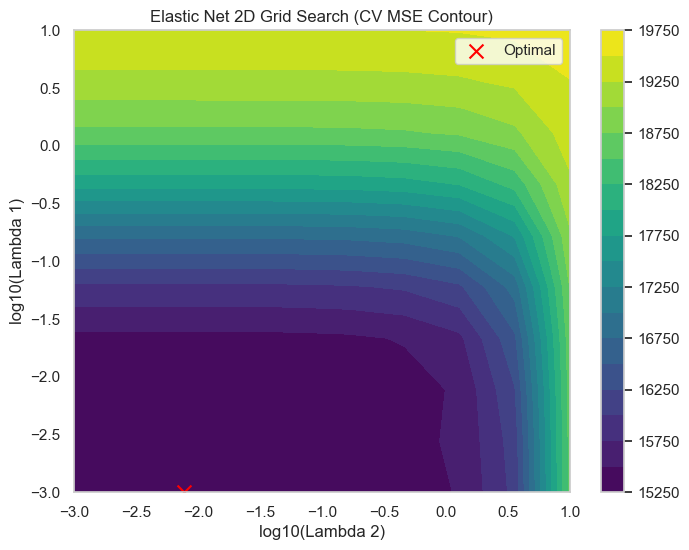

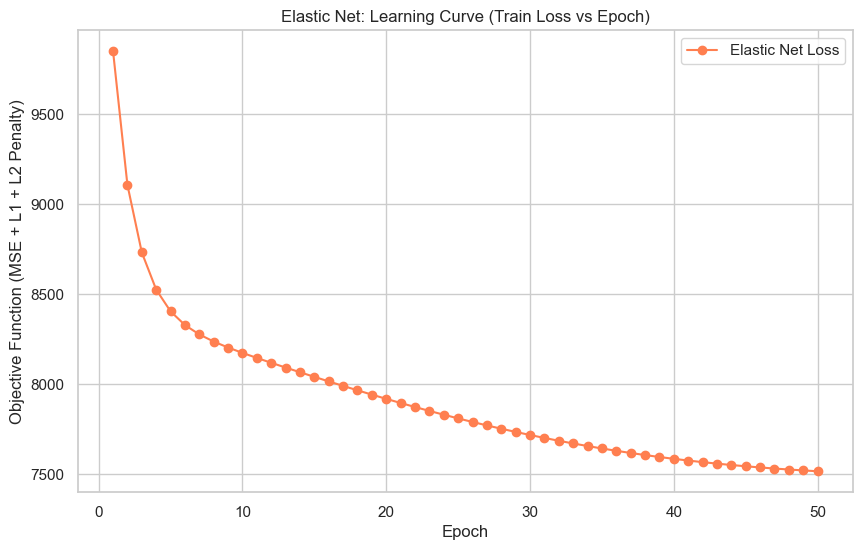

[Elastic Net] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17737.57 ± 9402.52
  - CV_RMSE (Mean ± Std): 128.63 ± 34.52
  - CV_MAE (Mean ± Std): 100.73 ± 28.57
  - CV_R2 (Mean ± Std): 0.1640 ± 0.2963
  - Val MSE: 33678.8993
  - Val RMSE: 183.5181
  - Val MAE: 149.2270
  - Val R2: 0.2971
  - Test MSE: 33586.3446
  - Test RMSE: 183.2658
  - Test MAE: 141.9452
  - Test R2: 0.3091


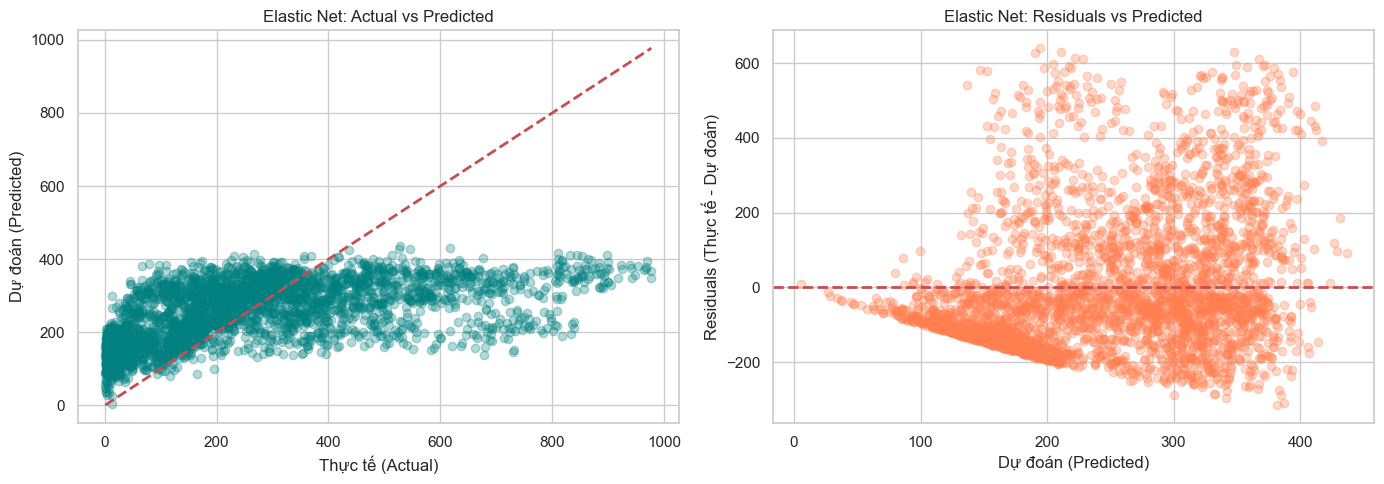

In [24]:
def elastic_net(X, y, lam1=1.0, lam2=1.0, epochs=30):
    m, n = X.shape
    w = np.zeros(n)
    losses = []

    for epoch in range(epochs):
        for j in range(n):
            X_j = X[:, j]
            y_pred_no_j = X.dot(w) - w[j] * X_j
            rho = X_j.T.dot(y - y_pred_no_j)

            if j == 0:
                w[j] = rho / (X_j.T.dot(X_j))
            else:
                w[j] = soft_threshold(rho, m * lam1) / (X_j.T.dot(X_j) + m * lam2)

        # Loss: 1/2m * MSE + l1*|w| + l2/2*w^2
        current_loss = (
            np.mean((X.dot(w) - y) ** 2) / 2.0
            + lam1 * np.sum(np.abs(w[1:]))
            + (lam2 / 2.0) * np.sum(w[1:] ** 2)
        )
        losses.append(current_loss)

    return w, losses


lam1_grid = np.logspace(-3, 1, 10)
lam2_grid = np.logspace(-3, 1, 10)
cv_errors_elastic = np.zeros((len(lam1_grid), len(lam2_grid)))

kf_el = KFold(n_splits=5, shuffle=True, random_state=42)
for i, l1 in enumerate(lam1_grid):
    for j, l2 in enumerate(lam2_grid):
        fold_errs = []
        for train_index, val_index in kf_el.split(X_train_scaled_b):
            X_fold_train, X_fold_val = (
                X_train_scaled_b[train_index],
                X_train_scaled_b[val_index],
            )
            y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

            w_opt, _ = elastic_net(
                X_fold_train, y_fold_train, lam1=l1, lam2=l2, epochs=20
            )
            y_pred = X_fold_val.dot(w_opt)
            fold_errs.append(np.mean((y_fold_val - y_pred) ** 2))
        cv_errors_elastic[i, j] = np.mean(fold_errs)

min_idx = np.unravel_index(np.argmin(cv_errors_elastic), cv_errors_elastic.shape)
best_lam1_el = lam1_grid[min_idx[0]]
best_lam2_el = lam2_grid[min_idx[1]]
print(f"Optimal Lam1 for Elastic Net: {best_lam1_el:.5f}")
print(f"Optimal Lam2 for Elastic Net: {best_lam2_el:.5f}")

L1, L2 = np.meshgrid(lam2_grid, lam1_grid)
plt.figure(figsize=(8, 6))
cp = plt.contourf(
    np.log10(L2), np.log10(L1), cv_errors_elastic, levels=20, cmap="viridis"
)
plt.colorbar(cp)
plt.scatter(
    np.log10(best_lam2_el),
    np.log10(best_lam1_el),
    color="red",
    marker="x",
    s=100,
    label="Optimal",
)
plt.xlabel("log10(Lambda 2)")
plt.ylabel("log10(Lambda 1)")
plt.title("Elastic Net 2D Grid Search (CV MSE Contour)")
plt.legend()
plt.show()

w_elastic, elastic_losses = elastic_net(
    X_train_scaled_b, y_train, lam1=best_lam1_el, lam2=best_lam2_el, epochs=50
)

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, 51), elastic_losses, marker="o", color="coral", label="Elastic Net Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Objective Function (MSE + L1 + L2 Penalty)")
plt.title("Elastic Net: Learning Curve (Train Loss vs Epoch)")
plt.legend()
plt.show()


def fit_pred_elastic(X_tr, y_tr, X_val):
    w, _ = elastic_net(X_tr, y_tr, lam1=best_lam1_el, lam2=best_lam2_el, epochs=50)
    return X_val.dot(w), w


_ = evaluate_model(
    "Elastic Net",
    fit_pred_elastic,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
    X_val_scaled_b,
    y_val,
)

### 3.4 Lựa chọn đặc trưng (Feature Selection)
1. Lasso Nonzero Coefficients: Các biến có hệ số w khác 0
2. Forward Stepwise Selection: Thêm từng biến làm giảm MSE validation nhiều nhất
3. Backward Elimination: Chặt dần từ full model biến ít ảnh hưởng nhất

In [25]:

feature_names = list(
    train_df.drop(columns=features_to_drop + ["cnt"], errors="ignore").columns
)

# 1. Lasso Nonzero
w_lasso, _ = lasso_cd(X_train_scaled_b, y_train, best_lam_lasso, epochs=50)
lasso_selected = []
for i, w_val in enumerate(w_lasso[1:]):
    if abs(w_val) > 1e-5:
        lasso_selected.append(feature_names[i])


# Helper measure MSE of a subset
def cv_err_subset(subset_indices):
    if len(subset_indices) == 0:
        return np.mean((y_train - np.mean(y_train)) ** 2)

    kf_sub = KFold(n_splits=5, shuffle=True, random_state=42)
    X_sub = X_train_scaled[:, subset_indices]
    X_sub_b = np.c_[np.ones((len(X_sub), 1)), X_sub]

    cv_errs = []
    for tr_idx, val_idx in kf_sub.split(X_sub_b):
        X_tr_f, X_val_f = X_sub_b[tr_idx], X_sub_b[val_idx]
        y_tr_f, y_val_f = y_train[tr_idx], y_train[val_idx]
        w_f = np.linalg.pinv(X_tr_f.T.dot(X_tr_f)).dot(X_tr_f.T).dot(y_tr_f)
        y_pred_f = X_val_f.dot(w_f)
        cv_errs.append(np.mean((y_val_f - y_pred_f) ** 2))
    return np.mean(cv_errs)


# 2. Forward Stepwise
forward_selected_indices = []
remaining_indices = list(range(len(feature_names)))
best_forward_mse = cv_err_subset([])

while remaining_indices:
    best_candidate = None
    best_candidate_mse = best_forward_mse

    for idx in remaining_indices:
        test_subset = forward_selected_indices + [idx]
        mse = cv_err_subset(test_subset)
        if mse < best_candidate_mse:
            best_candidate = idx
            best_candidate_mse = mse

    if best_candidate is not None:
        forward_selected_indices.append(best_candidate)
        remaining_indices.remove(best_candidate)
        best_forward_mse = best_candidate_mse
    else:
        break

forward_selected = [feature_names[i] for i in forward_selected_indices]

# 3. Backward Elimination
backward_selected_indices = list(range(len(feature_names)))
best_backward_mse = cv_err_subset(backward_selected_indices)

while len(backward_selected_indices) > 1:
    worst_candidate = None
    best_candidate_mse = best_backward_mse

    for idx in backward_selected_indices:
        test_subset = backward_selected_indices.copy()
        test_subset.remove(idx)
        mse = cv_err_subset(test_subset)
        if mse < best_candidate_mse:
            worst_candidate = idx
            best_candidate_mse = mse

    if worst_candidate is not None:
        backward_selected_indices.remove(worst_candidate)
        best_backward_mse = best_candidate_mse
    else:
        break

backward_selected = [feature_names[i] for i in backward_selected_indices]

print("\n" + "=" * 60)
print("=== TỔNG KẾT FEATURE SELECTION ===")
print("=" * 60)
print(f"Lasso Selected ({len(lasso_selected)} features): {lasso_selected}")
print(
    f"Forward Stepwise Selected ({len(forward_selected)} features): {forward_selected}"
)
print(
    f"Backward Elimination Selected ({len(backward_selected)} features): {backward_selected}"
)


=== TỔNG KẾT FEATURE SELECTION ===
Lasso Selected (12 features): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Forward Stepwise Selected (11 features): ['temp', 'hr', 'yr', 'hum', 'season', 'atemp', 'holiday', 'weathersit', 'weekday', 'mnth', 'windspeed']
Backward Elimination Selected (10 features): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'weathersit', 'atemp', 'hum', 'windspeed']


## 4. Hàm Cơ Sở Phi Tuyến (Nonlinear Basis Functions)
Lựa chọn: Polynomial, Gaussian RBF, B-Spline. Phân tích Ablation và Interaction.


=== 4.1. Áp dụng 3 Loại Hàm Cơ Sở ===
[Ridge + Polynomial (deg=2)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 14299.84 ± 7375.48
  - CV_RMSE (Mean ± Std): 115.92 ± 29.36
  - CV_MAE (Mean ± Std): 91.59 ± 23.63
  - CV_R2 (Mean ± Std): 0.2941 ± 0.3346
  - Val MSE: 25566.6651
  - Val RMSE: 159.8958
  - Val MAE: 124.9430
  - Val R2: 0.4664
  - Test MSE: 32942.1734
  - Test RMSE: 181.4998
  - Test MAE: 126.5472
  - Test R2: 0.3224


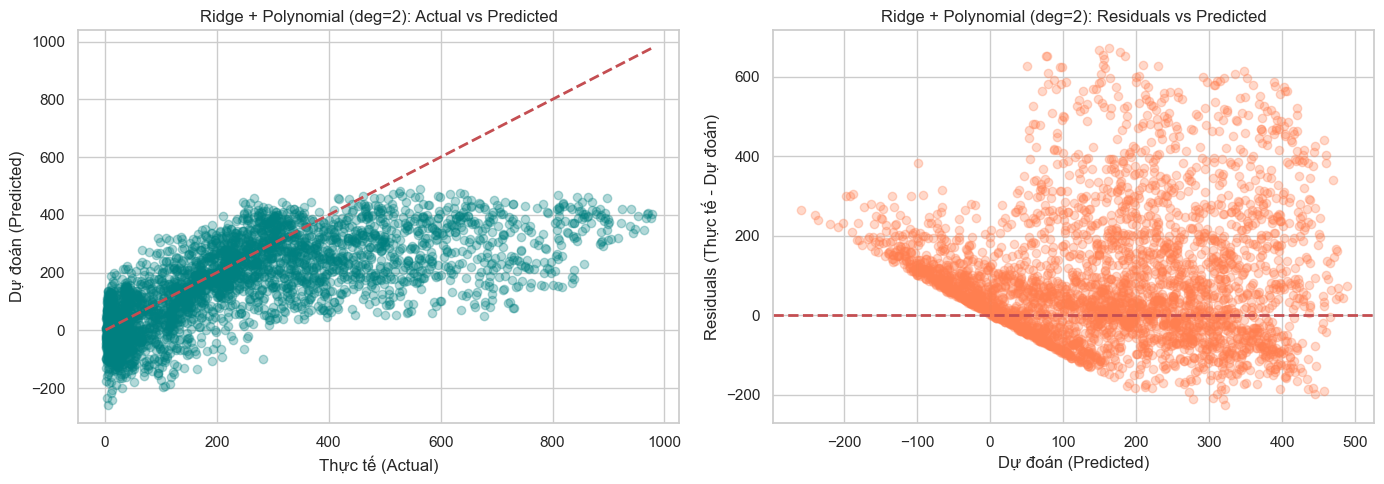

[Ridge + Gaussian RBF (n=100)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 11321.94 ± 4319.80
  - CV_RMSE (Mean ± Std): 104.38 ± 20.66
  - CV_MAE (Mean ± Std): 79.80 ± 15.27
  - CV_R2 (Mean ± Std): 0.3666 ± 0.3940
  - Val MSE: 15420.7646
  - Val RMSE: 124.1804
  - Val MAE: 93.4762
  - Val R2: 0.6782
  - Test MSE: 25488.6066
  - Test RMSE: 159.6515
  - Test MAE: 112.3989
  - Test R2: 0.4757


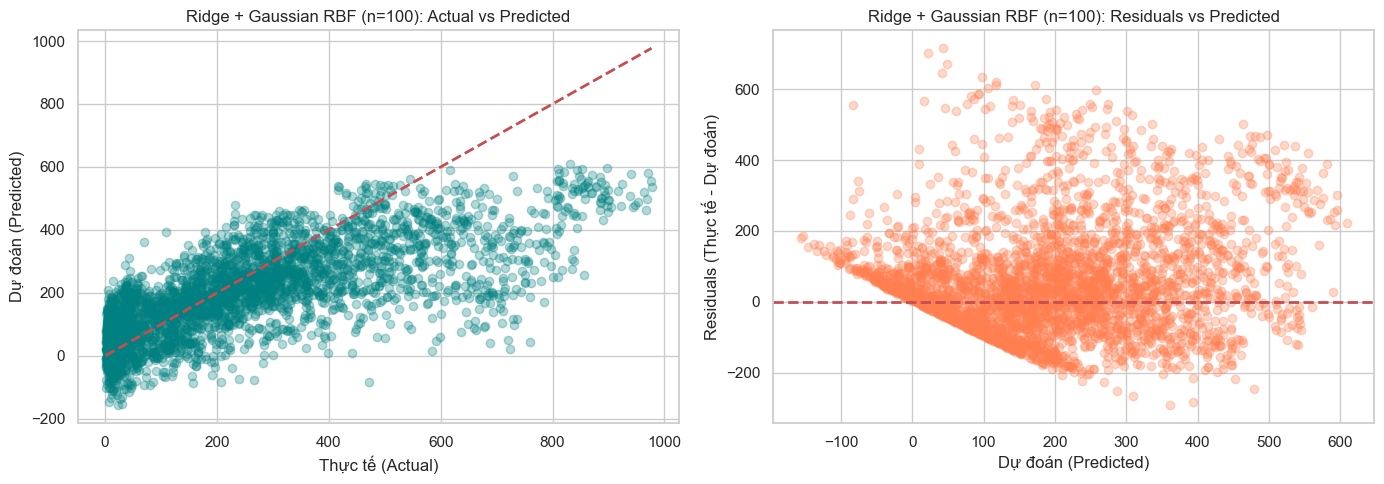

[Ridge + B-Spline (knots=4, deg=3)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 12682.66 ± 6562.44
  - CV_RMSE (Mean ± Std): 109.24 ± 27.35
  - CV_MAE (Mean ± Std): 83.48 ± 21.15
  - CV_R2 (Mean ± Std): 0.3554 ± 0.3727
  - Val MSE: 24688.0170
  - Val RMSE: 157.1242
  - Val MAE: 122.6134
  - Val R2: 0.4848
  - Test MSE: 25053.6864
  - Test RMSE: 158.2836
  - Test MAE: 117.5721
  - Test R2: 0.4846


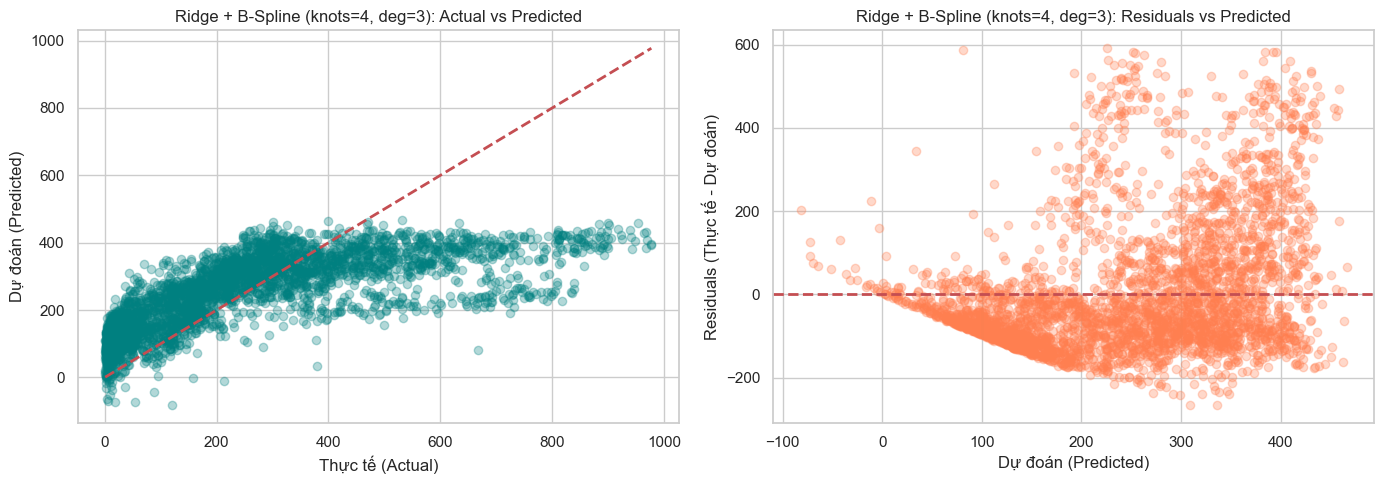

In [26]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Bọc Ridge với Sklearn để tiện dùng Transformation Pipelines
ridge_alpha = best_lam_ridge if "best_lam_ridge" in globals() else 10.0

print("\n" + "=" * 60)
print("=== 4.1. Áp dụng 3 Loại Hàm Cơ Sở ===")
print("=" * 60)


def fit_pred_sk_ridge(X_tr, y_tr, X_val):
    model = Ridge(alpha=ridge_alpha)
    model.fit(X_tr, y_tr)
    return model.predict(X_val), model


# 1. Polynomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_model = evaluate_model(
    "Ridge + Polynomial (deg=2)",
    fit_pred_sk_ridge,
    X_train_poly,
    y_train,
    X_test_poly,
    y_test,
    X_val_poly,
    y_val,
)

# 2. Gaussian RBF Features
rbf = RBFSampler(gamma=0.1, random_state=42, n_components=100)
X_train_rbf = rbf.fit_transform(X_train_scaled)
X_val_rbf = rbf.transform(X_val_scaled)
X_test_rbf = rbf.transform(X_test_scaled)
_ = evaluate_model(
    "Ridge + Gaussian RBF (n=100)",
    fit_pred_sk_ridge,
    X_train_rbf,
    y_train,
    X_test_rbf,
    y_test,
    X_val_rbf,
    y_val,
)

# 3. SplineTransformer (B-Splines)
spline = SplineTransformer(n_knots=4, degree=3, include_bias=False)
X_train_spline = spline.fit_transform(X_train_scaled)
X_val_spline = spline.transform(X_val_scaled)
X_test_spline = spline.transform(X_test_scaled)
_ = evaluate_model(
    "Ridge + B-Spline (knots=4, deg=3)",
    fit_pred_sk_ridge,
    X_train_spline,
    y_train,
    X_test_spline,
    y_test,
    X_val_spline,
    y_val,
)

### 4.2 Vẽ Validation Curve theo độ phức tạp

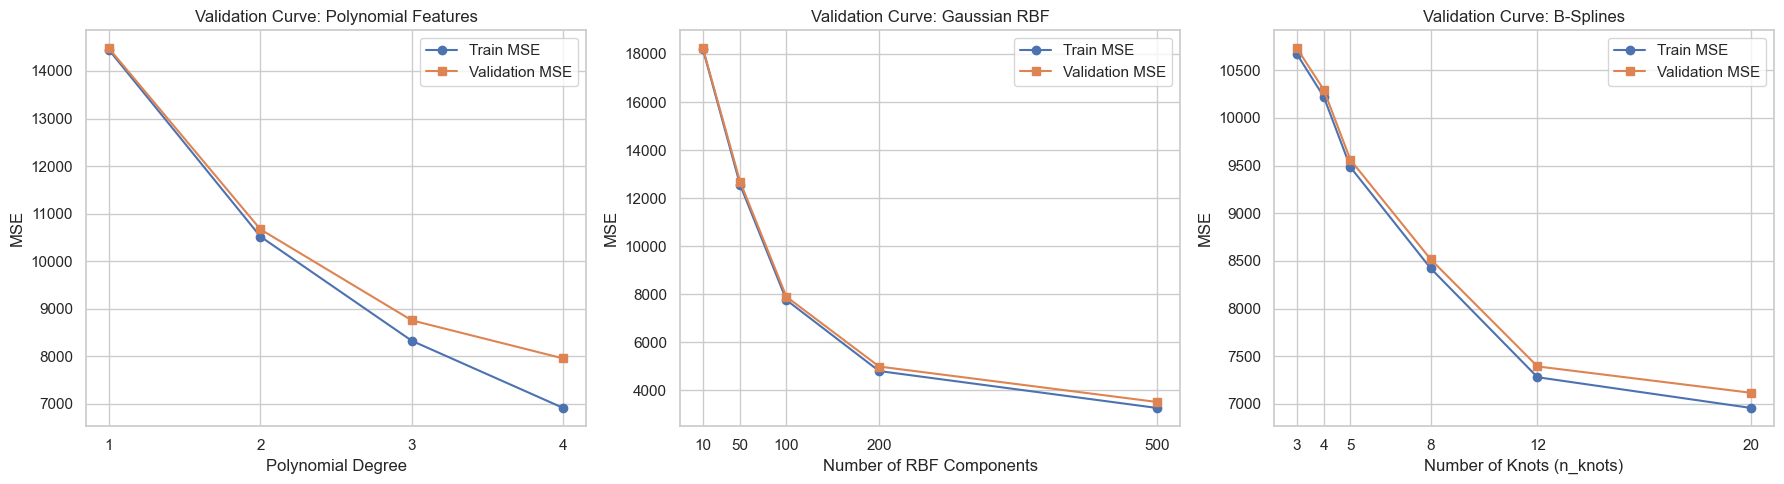

In [27]:
# Validation Curve: Bậc đa thức (Degree)
degrees = [1, 2, 3, 4]
poly_train_errs, poly_val_errs = [], []
kf_4 = KFold(n_splits=5, shuffle=True, random_state=42)

for d in degrees:
    poly_d = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_d = poly_d.fit_transform(X_train_scaled)

    t_err, v_err = [], []
    for tr_idx, val_idx in kf_4.split(X_poly_d):
        m = Ridge(alpha=ridge_alpha).fit(X_poly_d[tr_idx], y_train[tr_idx])
        t_err.append(mean_squared_error(y_train[tr_idx], m.predict(X_poly_d[tr_idx])))
        v_err.append(mean_squared_error(y_train[val_idx], m.predict(X_poly_d[val_idx])))

    poly_train_errs.append(np.mean(t_err))
    poly_val_errs.append(np.mean(v_err))

# Validation Curve: n_components (RBF)
n_comps = [10, 50, 100, 200, 500]
rbf_train_errs, rbf_val_errs = [], []

for n in n_comps:
    rbf_n = RBFSampler(gamma=0.1, n_components=n, random_state=42)
    X_rbf_n = rbf_n.fit_transform(X_train_scaled)

    t_err, v_err = [], []
    for tr_idx, val_idx in kf_4.split(X_rbf_n):
        m = Ridge(alpha=ridge_alpha).fit(X_rbf_n[tr_idx], y_train[tr_idx])
        t_err.append(mean_squared_error(y_train[tr_idx], m.predict(X_rbf_n[tr_idx])))
        v_err.append(mean_squared_error(y_train[val_idx], m.predict(X_rbf_n[val_idx])))

    rbf_train_errs.append(np.mean(t_err))
    rbf_val_errs.append(np.mean(v_err))

# Validation Curve: B-Spline (Số lượng knots)
knots_list = [3, 4, 5, 8, 12, 20]  # n_knots tối thiểu là 3 đối với degree=3
spline_train_errs, spline_val_errs = [], []

for k in knots_list:
    spline_k = SplineTransformer(n_knots=k, degree=3, include_bias=False)
    X_spline_k = spline_k.fit_transform(X_train_scaled)

    t_err, v_err = [], []
    for tr_idx, val_idx in kf_4.split(X_spline_k):
        m = Ridge(alpha=ridge_alpha).fit(X_spline_k[tr_idx], y_train[tr_idx])
        t_err.append(mean_squared_error(y_train[tr_idx], m.predict(X_spline_k[tr_idx])))
        v_err.append(
            mean_squared_error(y_train[val_idx], m.predict(X_spline_k[val_idx]))
        )

    spline_train_errs.append(np.mean(t_err))
    spline_val_errs.append(np.mean(v_err))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(degrees, poly_train_errs, label="Train MSE", marker="o")
axes[0].plot(degrees, poly_val_errs, label="Validation MSE", marker="s")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("MSE")
axes[0].set_title("Validation Curve: Polynomial Features")
axes[0].set_xticks(degrees)
axes[0].legend()

axes[1].plot(n_comps, rbf_train_errs, label="Train MSE", marker="o")
axes[1].plot(n_comps, rbf_val_errs, label="Validation MSE", marker="s")
axes[1].set_xlabel("Number of RBF Components")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation Curve: Gaussian RBF")
axes[1].set_xticks(n_comps)
axes[1].legend()

axes[2].plot(knots_list, spline_train_errs, label="Train MSE", marker="o")
axes[2].plot(knots_list, spline_val_errs, label="Validation MSE", marker="s")
axes[2].set_xlabel("Number of Knots (n_knots)")
axes[2].set_ylabel("MSE")
axes[2].set_title("Validation Curve: B-Splines")
axes[2].set_xticks(knots_list)
axes[2].legend()

plt.tight_layout()
plt.show()

### 4.3 Ablation Study: Tính quan trọng của nhóm đặc trưng

In [28]:
print("\n" + "=" * 60)
print("=== 4.3. Ablation Study ===")
print("=" * 60)

feat_names = list(
    train_df.drop(columns=features_to_drop + ["cnt"], errors="ignore").columns
)

# Cấu hình Nhóm đặc trưng
groups = {
    "Weather/Environment": [
        f
        for f in feat_names
        if f in ["weathersit", "temp", "atemp", "hum", "windspeed"]
    ],
    "Time/Date": [f for f in feat_names if f in ["yr", "mnth", "hr"]],
    "Calendar/Events": [
        f for f in feat_names if f in ["season", "holiday", "weekday", "workingday"]
    ],
}

base_model = Ridge(alpha=ridge_alpha).fit(X_train_scaled, y_train)
base_mse = mean_squared_error(y_test, base_model.predict(X_test_scaled))
print(f"Balseline MSE (Full features): {base_mse:.4f}\n")

performance_drop = {}
for group_name, group_feats in groups.items():
    if not group_feats:
        continue

    drop_indices = [feat_names.index(f) for f in group_feats]
    keep_indices = [i for i in range(len(feat_names)) if i not in drop_indices]

    X_tr_ablated = X_train_scaled[:, keep_indices]
    X_test_ablated = X_test_scaled[:, keep_indices]

    abl_model = Ridge(alpha=ridge_alpha).fit(X_tr_ablated, y_train)
    abl_pred = abl_model.predict(X_test_ablated)
    abl_mse = mean_squared_error(y_test, abl_pred)

    diff = abl_mse - base_mse
    performance_drop[group_name] = diff
    print(f"Drop '{group_name}' -> MSE: {abl_mse:.4f} (Chênh lệch: +{diff:.4f})")

worst_group = max(performance_drop, key=performance_drop.get)
print(f"\n=> Nhóm đặc trưng ảnh hưởng nghiêm trọng nhất khi thiếu vắng: {worst_group}")


=== 4.3. Ablation Study ===
Balseline MSE (Full features): 33654.5231

Drop 'Weather/Environment' -> MSE: 40774.6834 (Chênh lệch: +7120.1603)
Drop 'Time/Date' -> MSE: 44738.5062 (Chênh lệch: +11083.9831)
Drop 'Calendar/Events' -> MSE: 34320.9413 (Chênh lệch: +666.4182)

=> Nhóm đặc trưng ảnh hưởng nghiêm trọng nhất khi thiếu vắng: Time/Date


### 4.4 Phân tích Cơ chế Tương Tác ($x_i x_j$)

#### Interaction Only


=== 4.4. Phân tích Hiệu ứng Tương tác (Interaction Only) ===
[Ridge + All Interactions] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17318.86 ± 9278.09
  - CV_RMSE (Mean ± Std): 126.80 ± 35.23
  - CV_MAE (Mean ± Std): 98.57 ± 29.31
  - CV_R2 (Mean ± Std): 0.2081 ± 0.2036
  - Val MSE: 30261.3477
  - Val RMSE: 173.9579
  - Val MAE: 134.1643
  - Val R2: 0.3684
  - Test MSE: 39314.8675
  - Test RMSE: 198.2798
  - Test MAE: 136.6417
  - Test R2: 0.1913


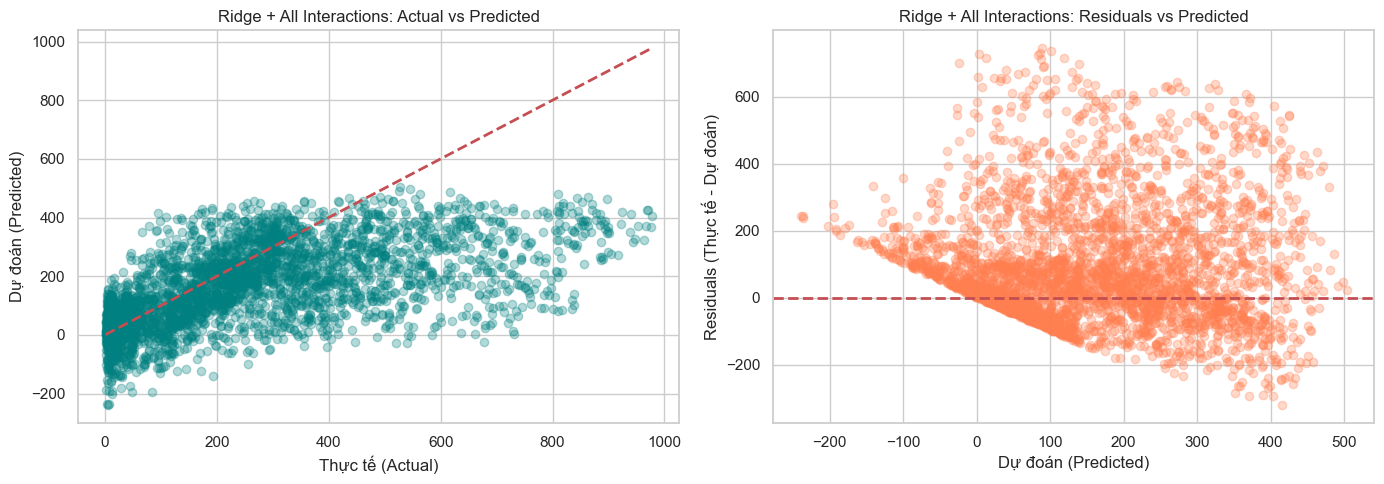

In [29]:
print("\n" + "=" * 60)
print("=== 4.4. Phân tích Hiệu ứng Tương tác (Interaction Only) ===")
print("=" * 60)

# Cấu hình PolynomialFeatures chỉ tạo tương tác chéo (không có bình phương)
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_inter = poly_inter.fit_transform(X_train_scaled)
X_val_inter = poly_inter.transform(X_val_scaled)
X_test_inter = poly_inter.transform(X_test_scaled)

inter_model = evaluate_model(
    "Ridge + All Interactions",
    fit_pred_sk_ridge,
    X_train_inter,
    y_train,
    X_test_inter,
    y_test,
    X_val_inter,
    y_val,
)

#### Phân tích Tương tác Thủ công (Domain Knowledge)
Bổ sung một vài biến tương tác cụ thể nhằm tối ưu kích thước mô hình thay vì tính tất cả.


=== 4.5. Phân tích Tương tác Thủ công (Tuỳ chỉnh) ===
[Ridge + Custom Interactions (temp*hum, hr*work)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17393.00 ± 9338.89
  - CV_RMSE (Mean ± Std): 127.03 ± 35.44
  - CV_MAE (Mean ± Std): 98.01 ± 30.14
  - CV_R2 (Mean ± Std): 0.2044 ± 0.2165
  - Val MSE: 32688.1659
  - Val RMSE: 180.7987
  - Val MAE: 145.8713
  - Val R2: 0.3178
  - Test MSE: 33397.8070
  - Test RMSE: 182.7507
  - Test MAE: 138.0981
  - Test R2: 0.3130


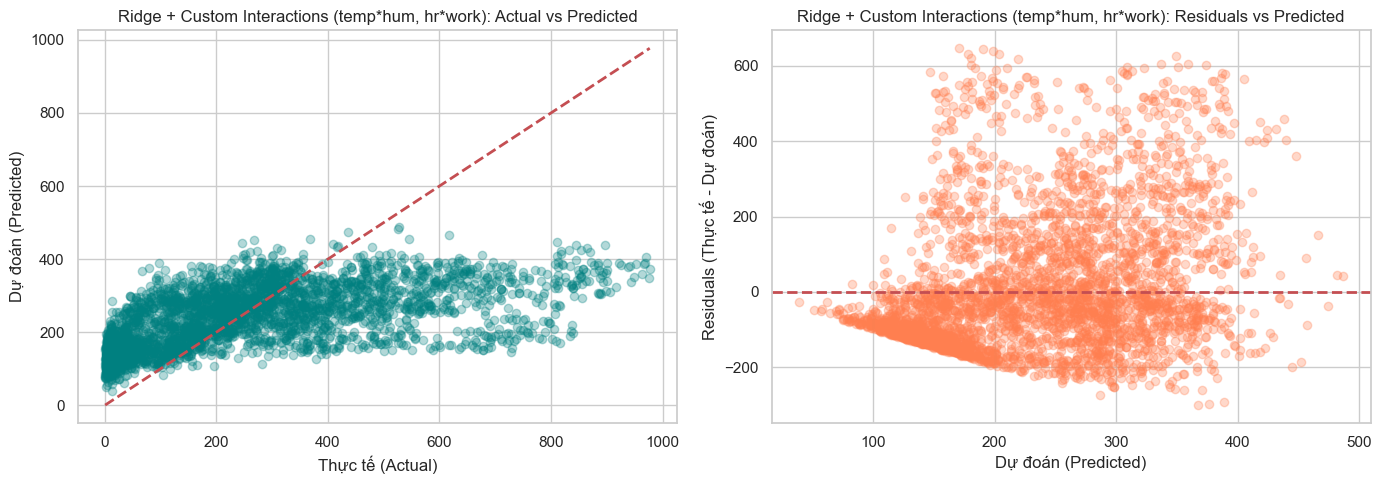

In [30]:
print("\n" + "=" * 60)
print("=== 4.5. Phân tích Tương tác Thủ công (Tuỳ chỉnh) ===")
print("=" * 60)
idx_temp = feat_names.index("temp")
idx_hum = feat_names.index("hum")
idx_hr = feat_names.index("hr")
idx_work = feat_names.index("workingday")

# Nối thêm tích của (temp * hum) và (hr * workingday) vào data gốc
X_train_custom = np.c_[
    X_train_scaled,
    X_train_scaled[:, idx_temp] * X_train_scaled[:, idx_hum],
    X_train_scaled[:, idx_hr] * X_train_scaled[:, idx_work],
]
X_val_custom = np.c_[
    X_val_scaled,
    X_val_scaled[:, idx_temp] * X_val_scaled[:, idx_hum],
    X_val_scaled[:, idx_hr] * X_val_scaled[:, idx_work],
]
X_test_custom = np.c_[
    X_test_scaled,
    X_test_scaled[:, idx_temp] * X_test_scaled[:, idx_hum],
    X_test_scaled[:, idx_hr] * X_test_scaled[:, idx_work],
]

custom_model = evaluate_model(
    "Ridge + Custom Interactions (temp*hum, hr*work)",
    fit_pred_sk_ridge,
    X_train_custom,
    y_train,
    X_test_custom,
    y_test,
    X_val_custom,
    y_val,
)

#### So sánh hiệu quả của các mô hình

In [31]:
print("\nSO SÁNH MỨC ĐỘ HIỆU QUẢ CỦA TƯƠNG TÁC:")
print(f"MSE Gốc Linear                    : {base_mse:.4f}")
print(
    f"MSE Gốc + 2 Tương tác (Tuỳ chỉnh) : {mean_squared_error(y_test, custom_model.predict(X_test_custom)):.4f}"
)
print(
    f"MSE Gốc + TẤT CẢ Tương tác chéo   : {mean_squared_error(y_test, inter_model.predict(X_test_inter)):.4f}"
)
print(
    f"MSE Bậc 2 Đầy đủ (Tương tác + x^2): {mean_squared_error(y_test, poly_model.predict(X_test_poly)):.4f}"
)


SO SÁNH MỨC ĐỘ HIỆU QUẢ CỦA TƯƠNG TÁC:
MSE Gốc Linear                    : 33654.5231
MSE Gốc + 2 Tương tác (Tuỳ chỉnh) : 33397.8070
MSE Gốc + TẤT CẢ Tương tác chéo   : 39314.8675
MSE Bậc 2 Đầy đủ (Tương tác + x^2): 32942.1734


**Nhận xét**:

- Việc thêm một số tương tác có chọn lọc giúp cải thiện nhẹ hiệu năng so với mô hình tuyến tính gốc.
- Tuy nhiên, thêm toàn bộ tương tác chéo lại làm MSE tăng mạnh → dấu hiệu overfitting / nhiễu.
- Mô hình đa thức bậc 2 đầy đủ cho kết quả tốt nhất, cho thấy dữ liệu có quan hệ phi tuyến rõ ràng.

**Kết luận:**
Việc bổ sung biến tương tác chỉ hiệu quả khi được kiểm soát hợp lý; thêm quá nhiều đặc trưng dễ làm mô hình kém tổng quát.

## 5. Mô hình Nâng cao

In [32]:
from sklearn.linear_model import (
    BayesianRidge,
    HuberRegressor,
    LinearRegression,
    RidgeCV,
    Ridge,
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
import time

### 5.1 Bayesian Regression & Evidence Maximization

Bayesian Ridge (Evidence Maximization):
 - Optimal Alpha (noise precision): 0.0001
 - Optimal Lambda (weight precision): 0.0001
 - LML Score (Maximized Evidence): -75569.0191
 - Training Time: 0.0058 sec
 - Test MSE: 33663.6854

Ridge CV:
 - Optimal Regularization Alpha: 85.3168
 - Training Time: 0.4742 sec
 - Test MSE: 34213.5101
[Bayesian Ridge] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17006.45 ± 9629.60
  - CV_RMSE (Mean ± Std): 125.21 ± 36.46
  - CV_MAE (Mean ± Std): 98.19 ± 31.31
  - CV_R2 (Mean ± Std): 0.2329 ± 0.2025
  - Val MSE: 34907.8869
  - Val RMSE: 186.8365
  - Val MAE: 154.8233
  - Val R2: 0.2715
  - Test MSE: 33663.6854
  - Test RMSE: 183.4767
  - Test MAE: 142.3818
  - Test R2: 0.3075


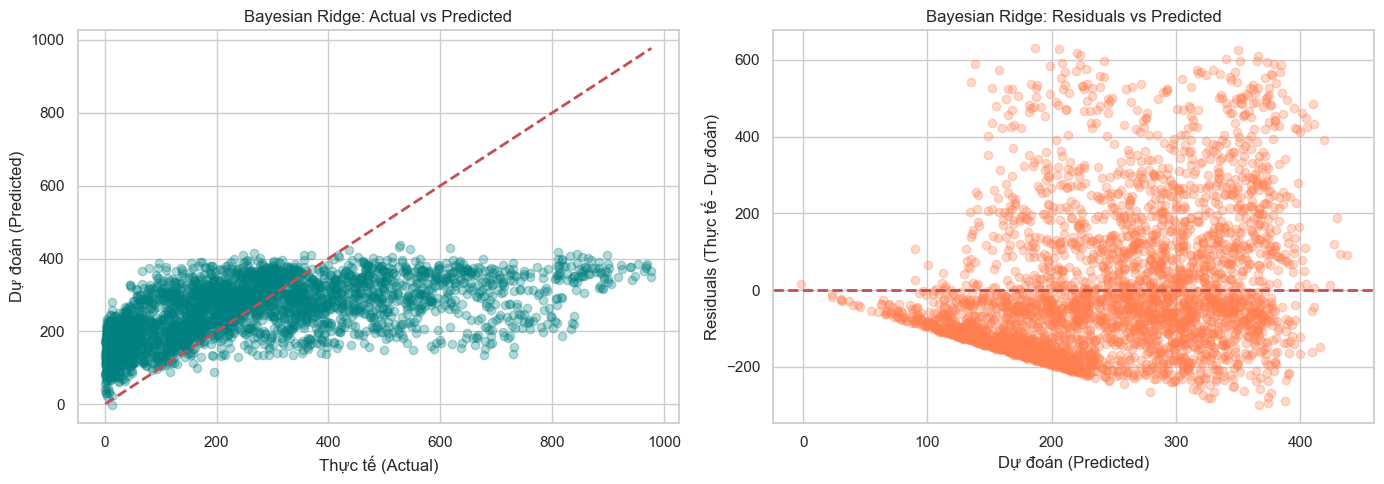

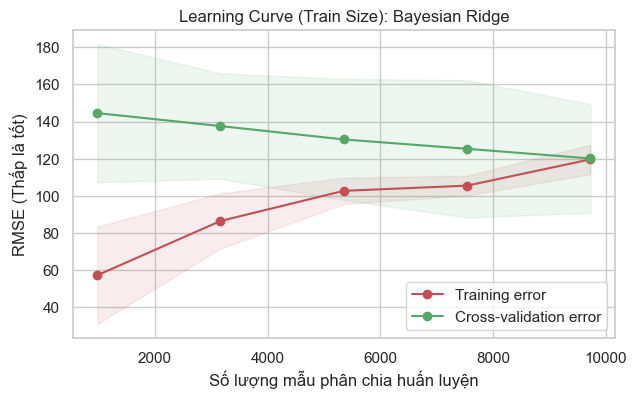

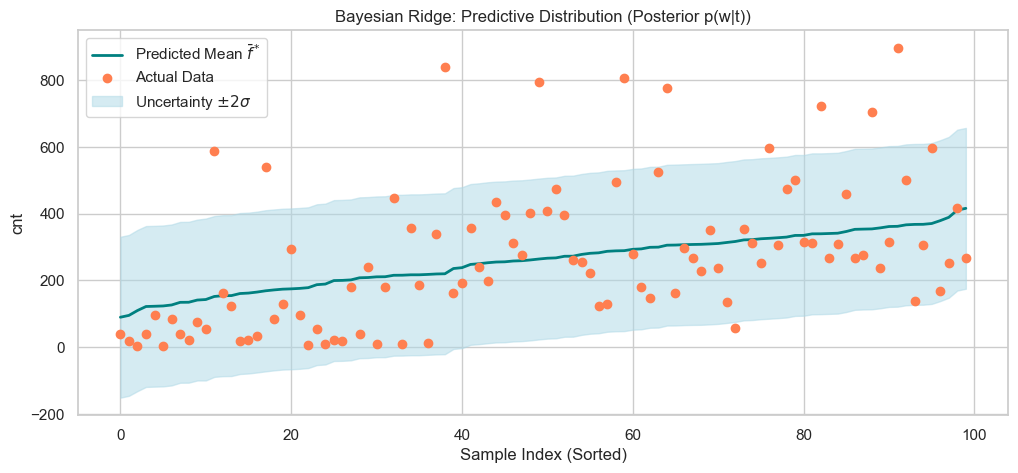

In [33]:

# Chạy Bayesian Ridge
start_bayes = time.time()
model_bayes = BayesianRidge(max_iter=300, compute_score=True)
model_bayes.fit(X_train_scaled, y_train)
time_bayes = time.time() - start_bayes

# Chạy RidgeCV để so sánh thời gian và MSE
start_ridgecv = time.time()
ridge_cv_model = RidgeCV(alphas=np.logspace(-2, 4, 30), cv=10)
ridge_cv_model.fit(X_train_scaled, y_train)
time_ridgecv = time.time() - start_ridgecv

print(f"Bayesian Ridge (Evidence Maximization):")
print(f" - Optimal Alpha (noise precision): {model_bayes.alpha_:.4f}")
print(f" - Optimal Lambda (weight precision): {model_bayes.lambda_:.4f}")
print(f" - LML Score (Maximized Evidence): {model_bayes.scores_[-1]:.4f}")
print(f" - Training Time: {time_bayes:.4f} sec")
print(
    f" - Test MSE: {mean_squared_error(y_test, model_bayes.predict(X_test_scaled)):.4f}\n"
)

print(f"Ridge CV:")
print(f" - Optimal Regularization Alpha: {ridge_cv_model.alpha_:.4f}")
print(f" - Training Time: {time_ridgecv:.4f} sec")
print(
    f" - Test MSE: {mean_squared_error(y_test, ridge_cv_model.predict(X_test_scaled)):.4f}"
)


def fit_pred_bayes(X_tr, y_tr, X_val):
    return model_bayes.predict(X_val), model_bayes


_ = evaluate_model(
    "Bayesian Ridge",
    fit_pred_bayes,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    BayesianRidge(max_iter=300), "Bayesian Ridge", X_train_scaled, y_train
)

# Plot Dải tự tin test
y_pred_bayes, y_std_bayes = model_bayes.predict(X_test_scaled, return_std=True)
np.random.seed(42)
indices = np.random.choice(len(y_test), 100, replace=False)
sorted_idx = np.argsort(y_pred_bayes[indices])
idx_to_plot = indices[sorted_idx]

plt.figure(figsize=(12, 5))
plt.plot(
    y_pred_bayes[idx_to_plot], color="teal", label="Predicted Mean $\\bar{f}^*$", lw=2
)
plt.scatter(
    range(100), y_test[idx_to_plot], color="coral", label="Actual Data", zorder=3
)
plt.fill_between(
    range(100),
    y_pred_bayes[idx_to_plot] - 2 * y_std_bayes[idx_to_plot],
    y_pred_bayes[idx_to_plot] + 2 * y_std_bayes[idx_to_plot],
    color="lightblue",
    alpha=0.5,
    label="Uncertainty $\\pm 2\\sigma$",
)
plt.title("Bayesian Ridge: Predictive Distribution (Posterior p(w|t))")
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("cnt")
plt.legend()
plt.show()

### 5.2 Kernel Ridge Regression (KRR)
Cài đặt với 2 Kernel: RBF và Polynomial và chọn tham số bằng Cross-Validation.

Optimal KRR Parameters: {'alpha': np.float64(0.01), 'degree': 2, 'gamma': np.float64(0.1), 'kernel': 'rbf'}
[Kernel Ridge (CV)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 2070.02 ± 3533.15
  - CV_RMSE (Mean ± Std): 37.07 ± 26.37
  - CV_MAE (Mean ± Std): 24.37 ± 17.56
  - CV_R2 (Mean ± Std): 0.9339 ± 0.0677
  - Val MSE: 11171.9633
  - Val RMSE: 105.6975
  - Val MAE: 69.5635
  - Val R2: 0.7668
  - Test MSE: 19765.9119
  - Test RMSE: 140.5913
  - Test MAE: 99.0981
  - Test R2: 0.5934


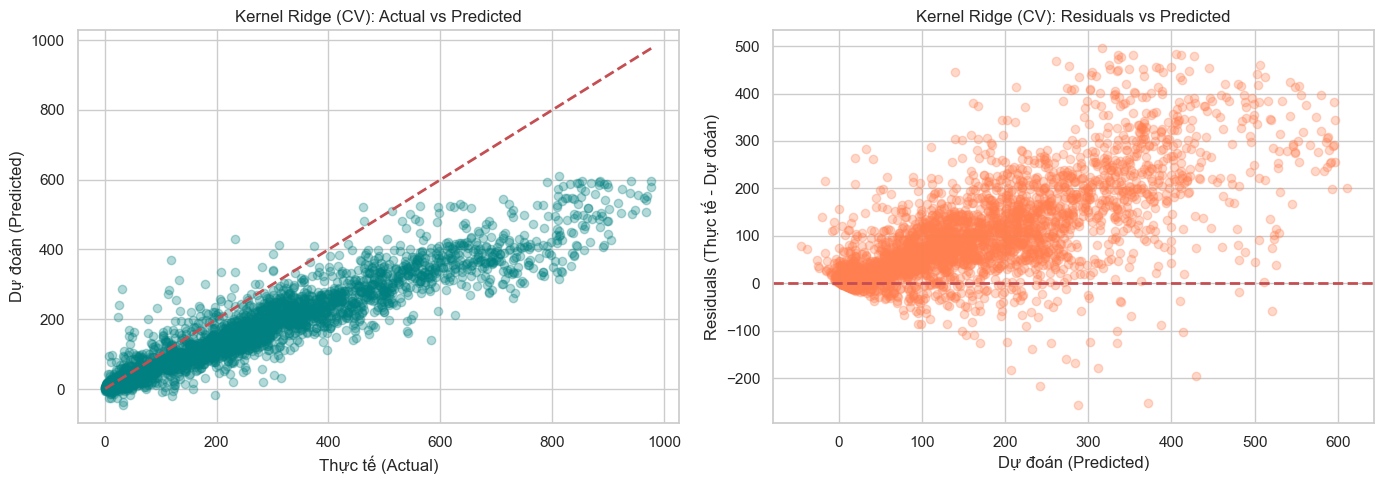

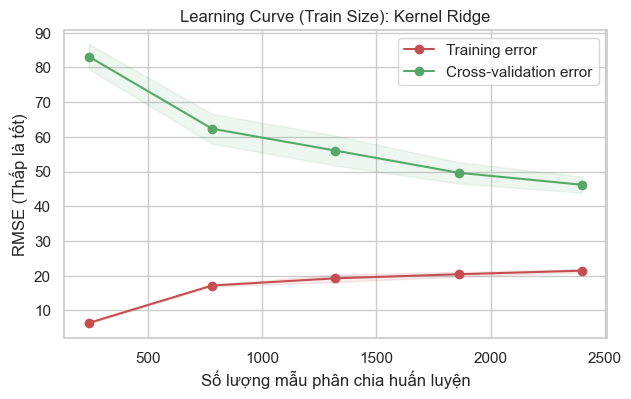

In [34]:

krr_params = {
    "kernel": ["rbf", "polynomial"],
    "alpha": np.logspace(-2, 2, 3),  # Regularization
    "gamma": np.logspace(-2, 0, 3),  # Bandwidth cho RBF / Poly
    "degree": [2, 3],  # Chỉ dùng nếu kernel là polynomial
}

# Subsample để GridSearch chạy nhanh hơn do KRR scale O(N^3)
X_train_sub, y_train_sub = resample(
    X_train_scaled, y_train, n_samples=3000, random_state=42
)

krr_grid = GridSearchCV(
    KernelRidge(), krr_params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1
)
krr_grid.fit(X_train_sub, y_train_sub)

print(f"Optimal KRR Parameters: {krr_grid.best_params_}")

model_krr = krr_grid.best_estimator_
model_krr.fit(X_train_scaled, y_train)


def fit_pred_kr(X_tr, y_tr, X_val):
    return model_krr.predict(X_val), model_krr


_ = evaluate_model(
    "Kernel Ridge (CV)",
    fit_pred_kr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    KernelRidge(**krr_grid.best_params_), "Kernel Ridge", X_train_sub, y_train_sub
)

### 5.3 Gaussian Process Regression (GPR)
Tối ưu Log-Marginal-Likelihood bằng gradient ascent L-BFGS-B (mặc định Sklearn)

Learned Kernel Parameters (Gradient Ascent): 31.6**2 * RBF(length_scale=0.209)
Maximized Log-Marginal-Likelihood: -38631.3580
[Gaussian Process] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 50035.90 ± 34396.05
  - CV_RMSE (Mean ± Std): 210.05 ± 76.90
  - CV_MAE (Mean ± Std): 150.38 ± 60.84
  - CV_R2 (Mean ± Std): -0.9905 ± 0.2535
  - Val MSE: 124093.8697
  - Val RMSE: 352.2696
  - Val MAE: 275.9500
  - Val R2: -1.5898
  - Test MSE: 110492.2608
  - Test RMSE: 332.4038
  - Test MAE: 248.7544
  - Test R2: -1.2729


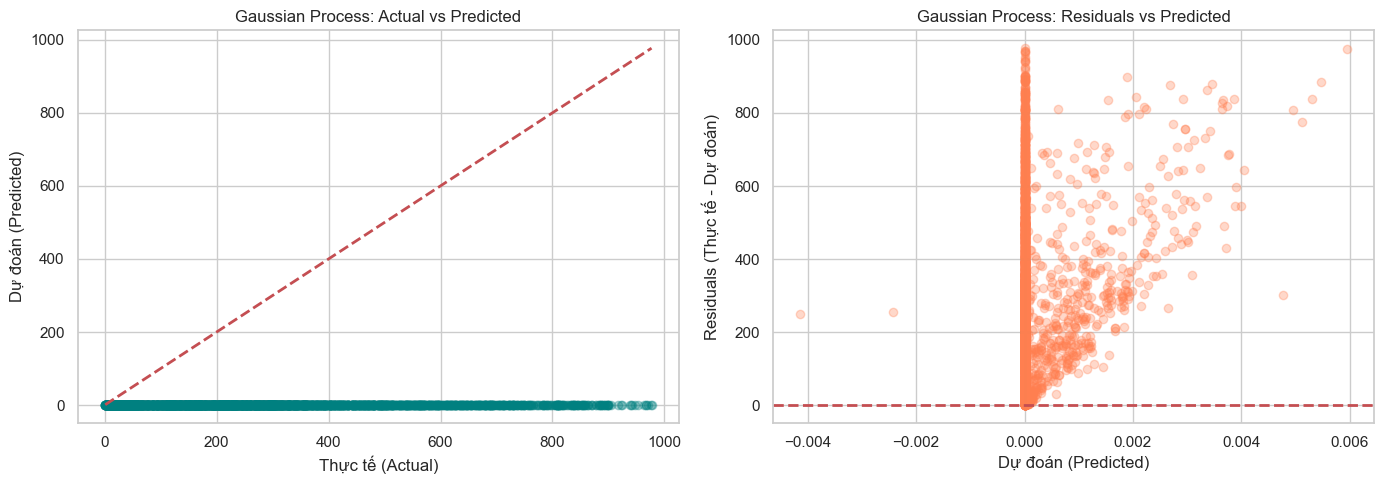

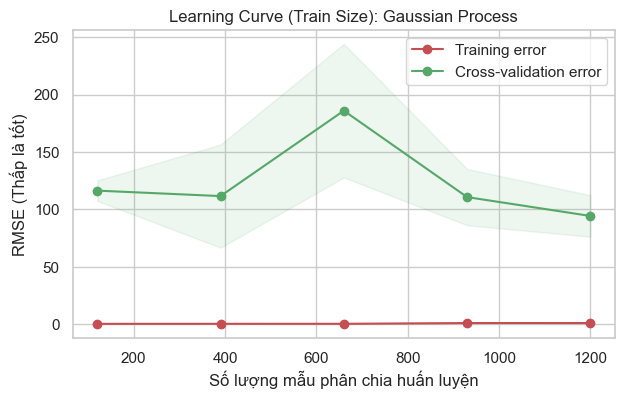

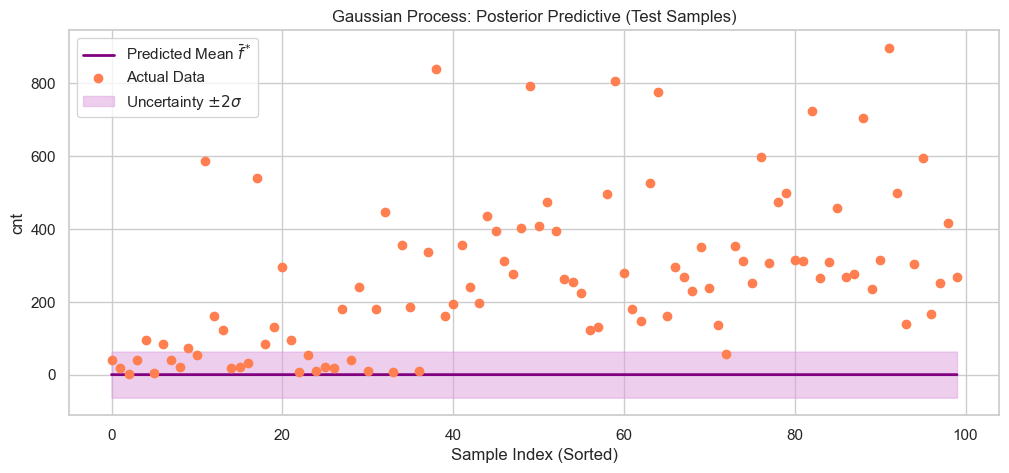

In [35]:
# Sử dụng ConstantKernel * RBF để học scale chiều cao và chiều ngang
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# GPR chạy rất lâu với N lớn, phải subsample
X_gpr_tr, y_gpr_tr = resample(X_train_scaled, y_train, n_samples=1500, random_state=42)

gpr = GaussianProcessRegressor(
    kernel=kernel, alpha=0.5, n_restarts_optimizer=2, random_state=42
)
gpr.fit(X_gpr_tr, y_gpr_tr)

print(f"Learned Kernel Parameters (Gradient Ascent): {gpr.kernel_}")
print(f"Maximized Log-Marginal-Likelihood: {gpr.log_marginal_likelihood_value_:.4f}")


def fit_pred_gpr(X_tr, y_tr, X_val):
    return gpr.predict(X_val), gpr


_ = evaluate_model(
    "Gaussian Process",
    fit_pred_gpr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    GaussianProcessRegressor(kernel=kernel, alpha=0.5, random_state=42),
    "Gaussian Process",
    X_gpr_tr,
    y_gpr_tr,
)

y_pred_gp, y_std_gp = gpr.predict(X_test_scaled, return_std=True)

plt.figure(figsize=(12, 5))
plt.plot(
    y_pred_gp[idx_to_plot], color="purple", label="Predicted Mean $\\bar{f}^*$", lw=2
)
plt.scatter(
    range(100), y_test[idx_to_plot], color="coral", label="Actual Data", zorder=3
)
plt.fill_between(
    range(100),
    y_pred_gp[idx_to_plot] - 2 * y_std_gp[idx_to_plot],
    y_pred_gp[idx_to_plot] + 2 * y_std_gp[idx_to_plot],
    color="plum",
    alpha=0.5,
    label="Uncertainty $\\pm 2\\sigma$",
)
plt.title("Gaussian Process: Posterior Predictive (Test Samples)")
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("cnt")
plt.legend()
plt.show()

### 5.4 Robust Regression (IRLS với Huber Loss)
So sánh tính Robust của Huber và OLS trên dữ liệu có Outliers

With Outliers - OLS MSE: 148666.5642
With Outliers - Huber MSE: 36761.6950


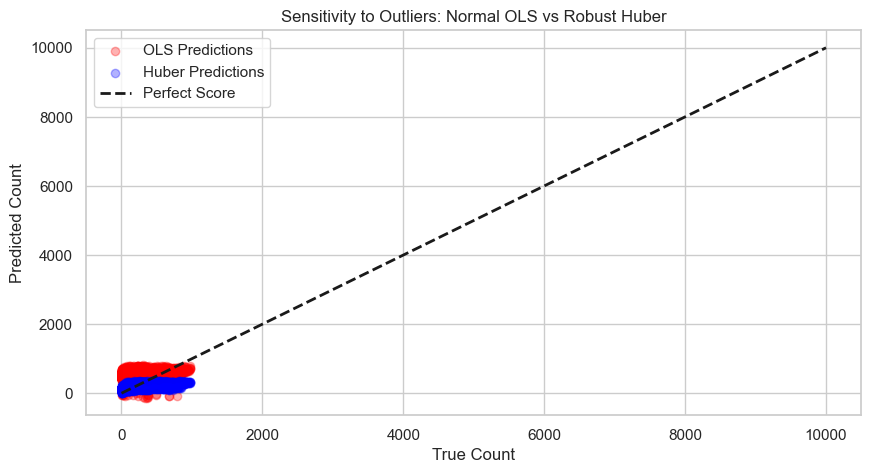

[Huber Robust] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 18433.44 ± 10257.68
  - CV_RMSE (Mean ± Std): 130.65 ± 36.95
  - CV_MAE (Mean ± Std): 95.68 ± 27.03
  - CV_R2 (Mean ± Std): 0.1501 ± 0.2743
  - Val MSE: 35123.5337
  - Val RMSE: 187.4127
  - Val MAE: 139.6328
  - Val R2: 0.2670
  - Test MSE: 37416.9335
  - Test RMSE: 193.4346
  - Test MAE: 134.5736
  - Test R2: 0.2303


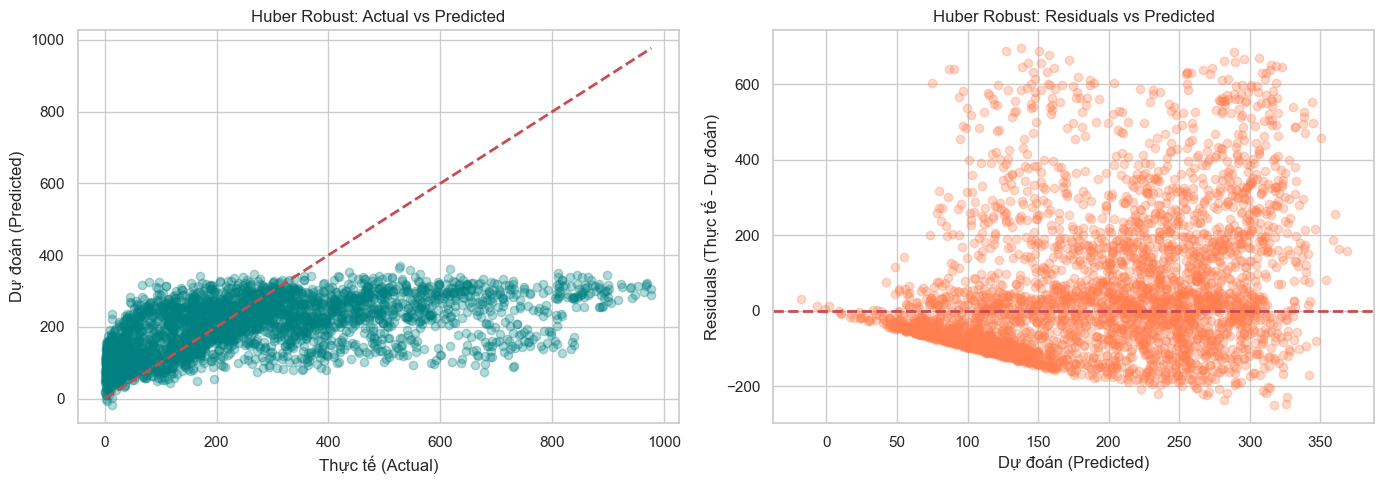

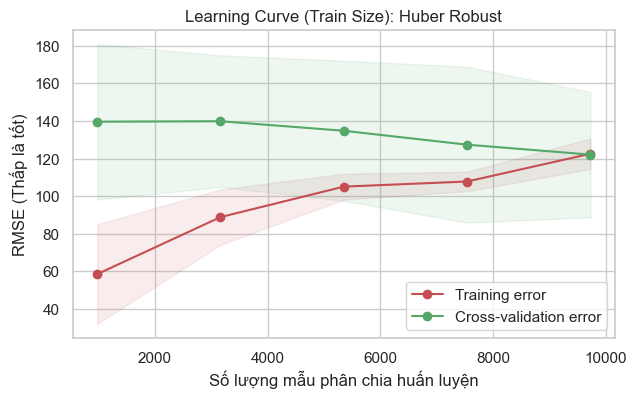

In [36]:
# Bơm outlier (Nhiễu cực lớn)
np.random.seed(42)
outlier_idx = np.random.choice(len(X_train_scaled), 200, replace=False)
y_train_outlier = y_train.copy().astype(float)
y_train_outlier[outlier_idx] = 15000  # Nhiễu lớn vô lý

ols_outlier = LinearRegression()
ols_outlier.fit(X_train_scaled, y_train_outlier)
ols_outlier_pred = ols_outlier.predict(X_test_scaled)
ols_mse = mean_squared_error(y_test, ols_outlier_pred)

# Huber Regressor (thực thi IRLS bên dưới)
huber_outlier = HuberRegressor(epsilon=1.35, max_iter=2000)
huber_outlier.fit(X_train_scaled, y_train_outlier)
huber_outlier_pred = huber_outlier.predict(X_test_scaled)
huber_mse = mean_squared_error(y_test, huber_outlier_pred)

print(f"With Outliers - OLS MSE: {ols_mse:.4f}")
print(f"With Outliers - Huber MSE: {huber_mse:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(y_test, ols_outlier_pred, alpha=0.3, color="red", label="OLS Predictions")
plt.scatter(
    y_test, huber_outlier_pred, alpha=0.3, color="blue", label="Huber Predictions"
)
plt.plot([0, 10000], [0, 10000], "k--", lw=2, label="Perfect Score")
plt.title("Sensitivity to Outliers: Normal OLS vs Robust Huber")
plt.xlabel("True Count")
plt.ylabel("Predicted Count")
plt.legend()
plt.show()


def fit_pred_huber(X_tr, y_tr, X_val):
    model = HuberRegressor(epsilon=1.35, max_iter=2000)
    model.fit(X_tr, y_tr)
    return model.predict(X_val), model


_ = evaluate_model(
    "Huber Robust",
    fit_pred_huber,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    HuberRegressor(epsilon=1.35, max_iter=2000), "Huber Robust", X_train_scaled, y_train
)

### 5.5 Phân tích Bias-Variance Thực Nghiệm (Bootstrap)
Bootstrap 200 lần để quan sát Error = Bias^2 + Variance

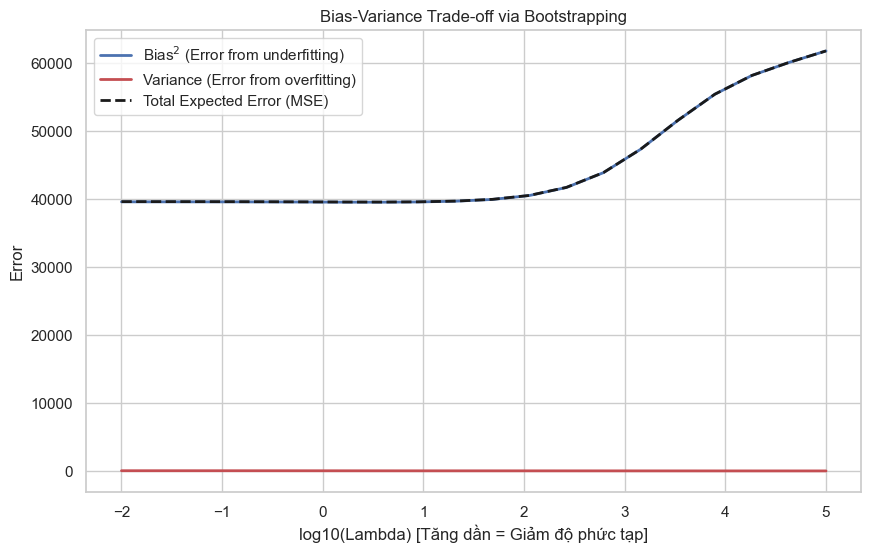

In [37]:
n_bootstraps = 200
lambda_range = np.logspace(-2, 5, 20)
test_size = min(1000, len(y_test))
X_test_sub = X_test_scaled[:test_size]
y_test_sub = y_test[:test_size]

biases_sq = []
variances = []
mses = []

for lam in lambda_range:
    all_preds = np.zeros((n_bootstraps, test_size))
    for b in range(n_bootstraps):
        X_b, y_b = resample(X_train_scaled, y_train, random_state=b)
        model = Ridge(alpha=lam)
        model.fit(X_b, y_b)
        all_preds[b, :] = model.predict(X_test_sub)

    expected_pred = np.mean(all_preds, axis=0)
    bias_sq = np.mean((expected_pred - y_test_sub) ** 2)
    variance = np.mean(np.var(all_preds, axis=0))
    mse = np.mean((all_preds - y_test_sub) ** 2)

    biases_sq.append(bias_sq)
    variances.append(variance)
    mses.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(
    np.log10(lambda_range),
    biases_sq,
    "b-",
    label="Bias$^2$ (Error from underfitting)",
    lw=2,
)
plt.plot(
    np.log10(lambda_range),
    variances,
    "r-",
    label="Variance (Error from overfitting)",
    lw=2,
)
plt.plot(np.log10(lambda_range), mses, "k--", label="Total Expected Error (MSE)", lw=2)
plt.xlabel("log10(Lambda) [Tăng dần = Giảm độ phức tạp]")
plt.ylabel("Error")
plt.title("Bias-Variance Trade-off via Bootstrapping")
plt.legend()
plt.grid(True)
plt.show()

## 6. Đánh giá Tổng hợp
### Bảng Phân Tích & Biểu Đồ


BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH
                                          Model CV_MSE (Mean ± Std) CV_RMSE (Mean ± Std) CV_MAE (Mean ± Std) CV_R2 (Mean ± Std)       Val MSE   Val RMSE    Val MAE    Val R2      Test MSE  Test RMSE   Test MAE   Test R2
                              Kernel Ridge (CV)   2070.02 ± 3533.15        37.07 ± 26.37       24.37 ± 17.56    0.9339 ± 0.0677  11171.963304 105.697509  69.563471  0.766843  19765.911919 140.591294  99.098055  0.593407
              Ridge + B-Spline (knots=4, deg=3)  12682.66 ± 6562.44       109.24 ± 27.35       83.48 ± 21.15    0.3554 ± 0.3727  24688.016987 157.124209 122.613403  0.484764  25053.686376 158.283563 117.572078  0.484636
                   Ridge + Gaussian RBF (n=100)  11321.94 ± 4319.80       104.38 ± 20.66       79.80 ± 15.27    0.3666 ± 0.3940  15420.764598 124.180371  93.476201  0.678171  25488.606584 159.651516 112.398871  0.475689
                     Ridge + Polynomial (deg=2)  14299.84 ± 7375.48       115.

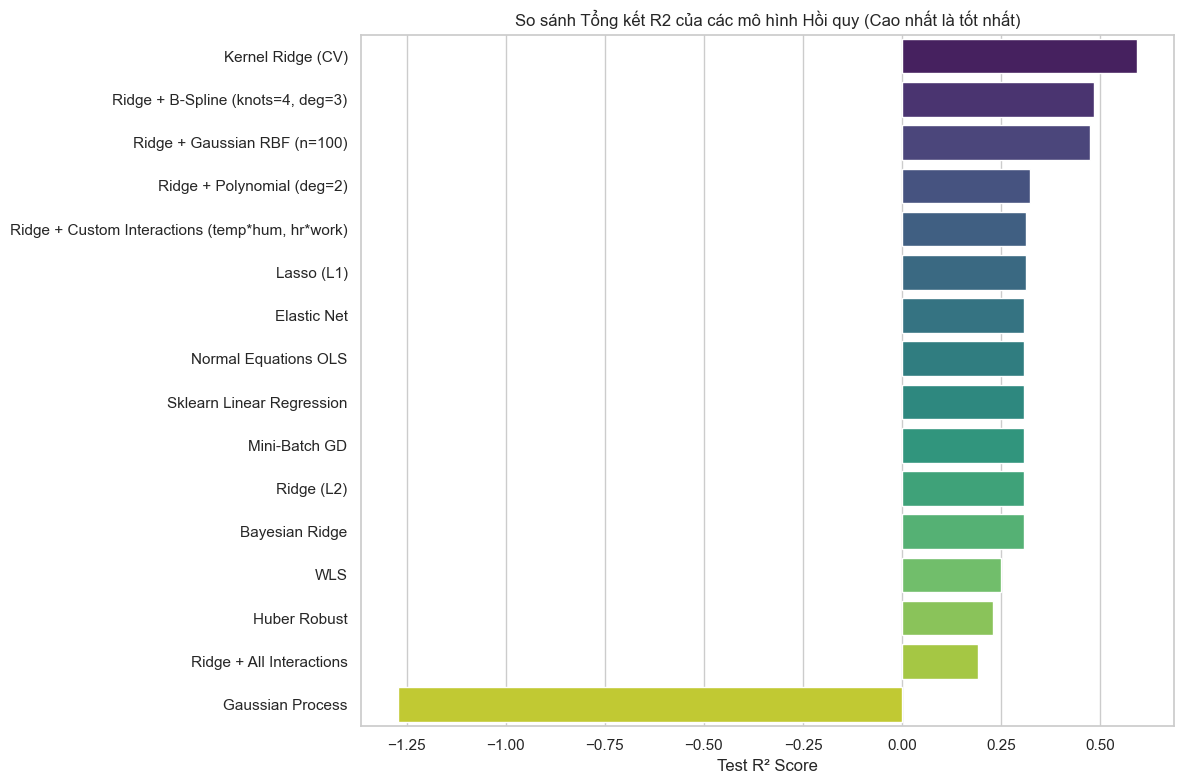

In [38]:
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon

print("\n" + "=" * 60)
print("BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH")
print("=" * 60)

# Tạo DataFrame từ metrics_list
results_df = pd.DataFrame(metrics_list)

# Sắp xếp theo Test R2 giảm dần
results_df_sorted = results_df.sort_values(by="Test R2", ascending=False)
print(results_df_sorted.to_string(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=results_df_sorted,
    x="Test R2",
    y="Model",
    palette="viridis",
)
plt.title("So sánh Tổng kết R2 của các mô hình Hồi quy (Cao nhất là tốt nhất)")
plt.xlabel("Test R² Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Kiểm định Thống kê (Wilcoxon Signed-Rank Test)
So sánh mô hình có lượng lỗi RMSE bé nhất trên tập Cross-Validation (K-Fold)
với tất cả các mô hình còn lại nhằm xác nhận ý nghĩa thống kê của sự cải thiện.

In [39]:
print("\n" + "=" * 60)
print("KIỂM ĐỊNH THỐNG KÊ WILCOXON SIGNED-RANK TEST (10-FOLD CV RMSE)")
print("=" * 60)

# Tìm mô hình tốt nhất (RMSE trung bình trên tập CV nhỏ nhất)
best_model_name = min(cv_scores_dict, key=lambda k: np.mean(cv_scores_dict[k]))
best_model_cv_scores = cv_scores_dict[best_model_name]

print(f"Mô hình tốt nhất (Tham chiếu): '{best_model_name}'")
print("-" * 60)

for m in metrics_list:
    current_model = m["Model"]
    if current_model == best_model_name:
        continue

    current_model_cv_scores = cv_scores_dict[current_model]

    # Thực hiện kiểm định Wilcoxon
    try:
        stat, p_value = wilcoxon(best_model_cv_scores, current_model_cv_scores)

        print(f"So sánh với '{current_model}':")
        print(f"   => p-value = {p_value:.4e}")
        if p_value < 0.05:
            print(
                f"   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). '{best_model_name}' thực sự ưu việt hơn."
            )
        else:
            print(
                f"   => KẾT LUẬN: KHÔNG có khác biệt có ý nghĩa thống kê. Hai mô hình hoạt động tương đương nhau."
            )
    except Exception as e:
        print(f"So sánh với '{current_model}': Bỏ qua kiểm định do ({str(e)})")
    print("-" * 60)


KIỂM ĐỊNH THỐNG KÊ WILCOXON SIGNED-RANK TEST (10-FOLD CV RMSE)
Mô hình tốt nhất (Tham chiếu): 'Kernel Ridge (CV)'
------------------------------------------------------------
So sánh với 'Normal Equations OLS':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Sklearn Linear Regression':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Mini-Batch GD':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'WLS':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
